<a href="https://colab.research.google.com/github/maxwpa/mestrado/blob/main/analise_inova-v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

install.packages(c("readxl","dplyr","tidyr","stringr","naniar","visdat",
                   "ggplot2","psych","e1071","GPArotation","corrplot",
                   "GPArotation","tidyverse","lavaan","janitor","semTools",
                   "BifactorIndicesCalculator", "EFAtools"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages(c("readxl", "dplyr", "tidyr", "stringr", "naniar", :
“installation of package ‘dplyr’ had non-zero exit status”
Warning message in install.packages(c("readxl", "dplyr", "tidyr", "stringr", "naniar", :
“installation of package ‘stringr’ had non-zero exit status”


In [2]:
# =========================================================
# PACOTES
# =========================================================

pacotes <- c("readxl","dplyr","tidyr","stringr","naniar","visdat",
                   "ggplot2","psych","e1071","GPArotation","corrplot",
                   "GPArotation","tidyverse","lavaan","janitor","semTools",
                   "BifactorIndicesCalculator", "EFAtools")

invisible(lapply(pacotes, library, character.only = TRUE))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element



Attaching package: ‘GPArotation’


The following objects are masked from ‘package:psych’:

    equamax, varimin


corrplot 0.95 loaded

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ psych::%+%()     masks ggplot2::%+%()
✖ psych::alpha()   masks ggplot2::alpha()
✖ e1071::element() masks ggplot2::element()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks 

In [3]:
# =========================================================
# 1. IMPORTAR BASE
# =========================================================

onet <- read.csv(
  "/content/onet-v6.txt",
  check.names = FALSE
)

# visualizar estrutura
glimpse(onet)

Rows: 1,084,860
Columns: 14
$ `O*NET-SOC Code`    <chr> "11-1011.00", "11-1011.00", "11-1011.00", "11-1011…
$ Title               <chr> "Chief Executives", "Chief Executives", "Chief Exe…
$ `Element ID`        <chr> "1.A.1.a.1", "1.A.1.a.1", "1.A.1.a.2", "1.A.1.a.2"…
$ `Element Name`      <chr> "Oral Comprehension", "Oral Comprehension", "Writt…
$ Date                <chr> "07/2014", "07/2014", "07/2014", "07/2014", "07/20…
$ `Scale ID`          <chr> "IM", "LV", "IM", "LV", "IM", "LV", "IM", "LV", "I…
$ `Scale Name`        <chr> "Importance", "Level", "Importance", "Level", "Imp…
$ `Data Value`        <dbl> 4.50, 4.88, 4.25, 4.62, 4.38, 5.00, 4.12, 4.62, 3.…
$ Type                <chr> "Abilities", "Abilities", "Abilities", "Abilities"…
$ Version             <dbl> 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22.1, 22…
$ `Version Year`      <int> 2017, 2017, 2017, 2017, 2017, 2017, 2017, 2017, 20…
$ Quarter             <chr> "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q4", "Q…
$ Year      

### Tratamento dos Dados

Inicialmente, foi realizada a importação da base de dados da ONET contendo informações ocupacionais longitudinais entre os anos de 2016 e 2026. Em seguida, foi criada uma variável denominada “Element and Scale”, resultante da combinação entre o nome do elemento ocupacional (“Element Name”) e o tipo de escala associado (“Scale Name”). Esse procedimento permitiu identificar de forma única cada atributo ocupacional mensurado pela ONET, distinguindo, por exemplo, medidas de importância, nível ou impacto referentes à mesma skill ou característica ocupacional.

Posteriormente, os valores da variável “Data Value” foram padronizados por meio da transformação em escore-z dentro de cada grupo de “Scale ID”. Essa etapa teve como objetivo tornar comparáveis variáveis originalmente medidas em escalas distintas, eliminando diferenças de magnitude entre métricas heterogêneas e permitindo futuras análises multivariadas, como PCA, CFA ou construção de índices sintéticos.

In [4]:
# =========================================================
# 2. AGRUPAR SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

In [5]:
# =========================================================
# 3. Z-SCORE DENTRO DE CADA SCALE ID
# =========================================================

onet <- onet %>%
  group_by(`Scale ID`) %>%
  mutate(
    z_Data_Value = as.numeric(scale(`Data Value`))
  ) %>%
  ungroup()

# verificar
summary(onet$z_Data_Value)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.86211 -0.72075  0.08133  0.00000  0.69091  3.25147 

#### Relatório

In [ ]:
# =========================================================
# RELATÓRIO GERAL
# =========================================================

# 1. Quantidade global de ocupações
n_ocupacoes_global <- onet %>%
  summarise(
    ocupacoes = n_distinct(`O*NET-SOC Code`)
  )

# 2. Ocupações e variáveis por Version Year
relatorio_ano <- onet %>%
  group_by(`Version Year`) %>%
  summarise(
    ocupacoes = n_distinct(`O*NET-SOC Code`),
    variaveis = n_distinct(`Element and Scale`),
    observacoes = n(),
    .groups = "drop"
  ) %>%
  arrange(`Version Year`)

# 3. Variáveis por Type
relatorio_type <- onet %>%
  group_by(Type) %>%
  summarise(
    variaveis = n_distinct(`Element and Scale`),
    elementos = n_distinct(`Element ID`),
    .groups = "drop"
  ) %>%
  arrange(desc(variaveis))

In [ ]:
# =========================================================
# EXIBIR RESULTADOS
# =========================================================

cat("\n========================================\n")
cat("RELATÓRIO O*NET\n")
cat("========================================\n")

cat("\nQuantidade global de ocupações:\n")
print(n_ocupacoes_global)

cat("\nOcupações e variáveis por Version Year:\n")
print(relatorio_ano)

cat("\nVariáveis por Type:\n")
print(relatorio_type)


RELATÓRIO O*NET

Quantidade global de ocupações:
# A tibble: 1 × 1
  ocupacoes
      <int>
1       798

Ocupações e variáveis por Version Year:
# A tibble: 5 × 4
  `Version Year` ocupacoes variaveis observacoes
           <int>     <int>     <int>       <int>
1           2017       683       320      214739
2           2019       612       320      192555
3           2021       715       320      224767
4           2023       715       320      224904
5           2025       725       320      227895

Variáveis por Type:
# A tibble: 4 × 3
  Type            variaveis elementos
  <chr>               <int>     <int>
1 Abilities             104        52
2 Work Activities        94        41
3 Skills                 72        35
4 Knowledge              68        33


In [ ]:
relatorio_completude <- onet %>%
  group_by(`Version Year`) %>%
  summarise(
    observacoes_reais = n(),
    ocupacoes = n_distinct(`O*NET-SOC Code`),
    variaveis = n_distinct(`Element and Scale`)
  ) %>%
  mutate(
    celulas_teoricas = ocupacoes * variaveis,
    completude = observacoes_reais / celulas_teoricas
  )

relatorio_completude

Version Year,observacoes_reais,ocupacoes,variaveis,celulas_teoricas,completude
<int>,<int>,<int>,<int>,<int>,<dbl>
2017,214739,683,320,218560,0.9825174
2019,192555,612,320,195840,0.9832261
2021,224767,715,320,228800,0.9823733
2023,224904,715,320,228800,0.9829720
2025,227895,725,320,232000,0.9823060


## Adequação do Dados Insatifatórios

### Missing Longitudinal de Amostragem Única

Após a padronização, foi conduzida uma análise exploratória de dados ausentes (missing data). Na base original em formato longo, observou-se ausência praticamente total de valores faltantes. Tanto as análises gerais quanto as análises por ano, tipo de variável e ocupação indicaram percentuais de missing iguais a zero. Isso demonstra que a base original apresenta elevada consistência observacional, isto é, os registros existentes estão completos.

Em seguida, foi construída uma matriz em formato wide, na qual cada linha passou a representar uma combinação ocupação-ano e cada coluna passou a representar uma skill ou característica ocupacional específica. Esse procedimento foi realizado por meio da função pivot_wider(), utilizando a variável “Element and Scale” como identificador das colunas. O objetivo dessa transformação foi preparar os dados para análises fatoriais, construção de índices latentes e modelos longitudinais multivariados.

Entretanto, após a transformação para o formato wide, observou-se um aumento expressivo no percentual de dados ausentes, atingindo aproximadamente 60,16% da matriz final. A inspeção detalhada revelou que esse missing não decorre de falhas de coleta ou erros de preenchimento, mas sim de um fenômeno estrutural relacionado à evolução histórica da própria base O*NET. Diversas variáveis foram introduzidas apenas nos anos mais recentes, enquanto outras aparecem somente em determinados módulos ocupacionais ou períodos específicos.

As visualizações longitudinais confirmaram esse comportamento. O heatmap de presença das ocupações mostrou que a cobertura ocupacional varia significativamente entre os anos, com ocupações surgindo, desaparecendo ou sendo reclassificadas ao longo do tempo. Além disso, verificou-se que determinados grupos de variáveis — especialmente aqueles relacionados a “Work Styles Impact”, “Distinctiveness Rank” e “Occupational Interests” — apresentam elevados percentuais de ausência, frequentemente superiores a 80%. Isso indica que tais atributos são relativamente novos dentro da taxonomia da O*NET e não estavam disponíveis nos anos anteriores.

Do ponto de vista metodológico, o resultado obtido possui implicações importantes. Os dados ausentes identificados não podem ser considerados aleatórios (“Missing Completely at Random” – MCAR). Pelo contrário, tratam-se de ausências estruturais associadas ao ano, ao tipo de variável e à evolução institucional da classificação ocupacional. Isso significa que técnicas simples de imputação podem produzir distorções analíticas relevantes, especialmente em modelos fatoriais ou longitudinais.

Substantivamente, os resultados sugerem que a própria ONET passou por um processo de transformação conceitual ao longo do tempo. As variáveis introduzidas recentemente concentram-se em dimensões relacionadas à criatividade, adaptabilidade, curiosidade intelectual, empatia, tolerância à ambiguidade e inovação, indicando uma ampliação da importância atribuída às competências cognitivas avançadas e socioemocionais no mercado de trabalho contemporâneo. Assim, além de representar um desafio metodológico para análises longitudinais, a evolução da estrutura da ONET também constitui evidência empírica de mudanças históricas na concepção de qualificação profissional e nas demandas ocupacionais da economia moderna.

In [ ]:
# =========================================================
# 4. CHECAR MISSING GERAL
# =========================================================

# quantidade de NA por variável
colSums(is.na(onet))

# porcentagem de NA por variável
round(colMeans(is.na(onet)) * 100, 2)

O*NET-SOC Code             Title              Year              Type 
                0                 0                 0                 0 
Element and Scale        Data Value      z_Data_Value 
                0                 0                 0

O*NET-SOC Code             Title              Year              Type 
                0                 0                 0                 0 
Element and Scale        Data Value      z_Data_Value 
                0                 0                 0

In [ ]:
# =========================================================
# 5. MISSING LONGITUDINAL POR ANO
# =========================================================

missing_year <- onet %>%
  group_by(Year) %>%
  summarise(
    n = n(),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    perc_missing = round(
      mean(is.na(across(everything()))) * 100,
      2
    )
  )

missing_year

Year,n,missing_total,perc_missing
<dbl>,<int>,<int>,<dbl>
2016,373341,0,0
2017,39186,0,0
2018,41988,0,0
2019,40950,0,0
2020,58155,0,0
2021,34772,0,0
2022,26545,0,0
2023,38209,0,0
2024,30217,0,0


In [ ]:
# =========================================================
# 6. MISSING POR TYPE E ANO
# =========================================================

missing_type_year <- onet %>%
  group_by(Year, Type) %>%
  summarise(
    n = n(),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    perc_missing = round(
      mean(is.na(across(everything()))) * 100,
      2
    ),
    .groups = "drop"
  )

missing_type_year

Year,Type,n,missing_total,perc_missing
<dbl>,<chr>,<int>,<int>,<dbl>
2016,Abilities,108844,0,0
2016,Interests,10134,0,0
2016,Knowledge,64580,0,0
2016,Skills,73455,0,0
2016,Work Activities,89064,0,0
2016,Work Styles,17130,0,0
2016,Work Values,10134,0,0
2017,Abilities,11855,0,0
2017,Knowledge,7071,0,0


In [ ]:
# =========================================================
# 7. MISSING POR O*NET-SOC CODE AO LONGO DO TEMPO
# =========================================================

missing_occ <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    anos_presentes = n_distinct(Year),
    missing_total = sum(across(everything(), ~sum(is.na(.x)))),
    .groups = "drop"
  ) %>%
  arrange(desc(missing_total))

missing_occ

O*NET-SOC Code,anos_presentes,missing_total
<chr>,<int>,<int>
11-1011.00,4,0
11-1011.03,3,0
11-1021.00,4,0
11-1031.00,3,0
11-2011.00,5,0
11-2011.01,1,0
11-2021.00,4,0
11-2022.00,4,0
11-2031.00,2,0


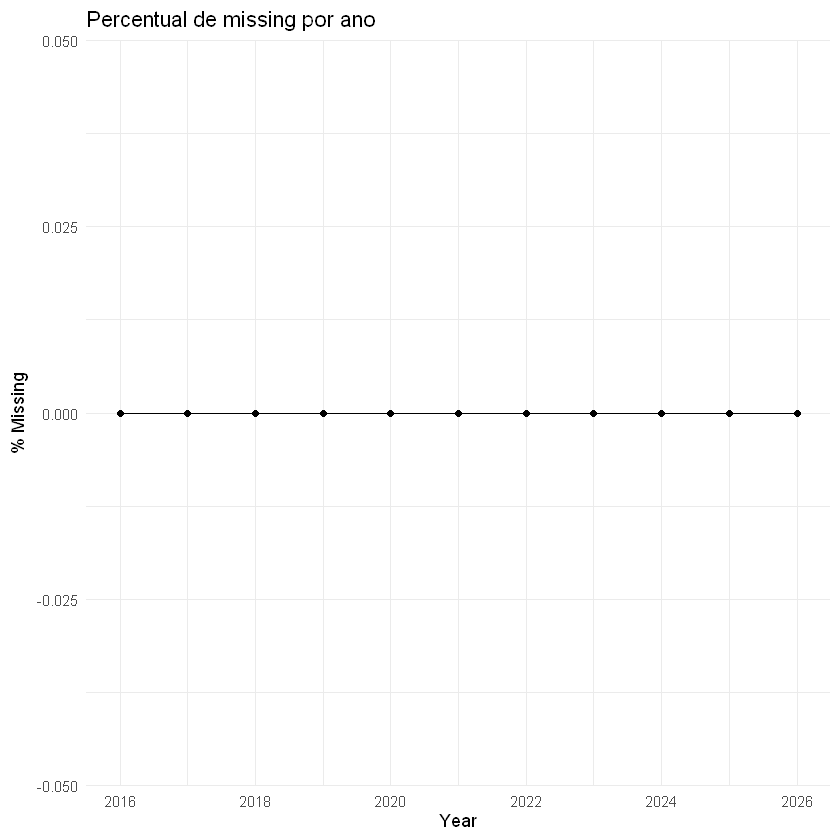

In [ ]:
# =========================================================
# 8. VISUALIZAÇÃO DE MISSING
# =========================================================

# mapa visual de missing
ggplot(missing_year,
       aes(x = Year, y = perc_missing)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    title = "Percentual de missing por ano",
    y = "% Missing"
  )

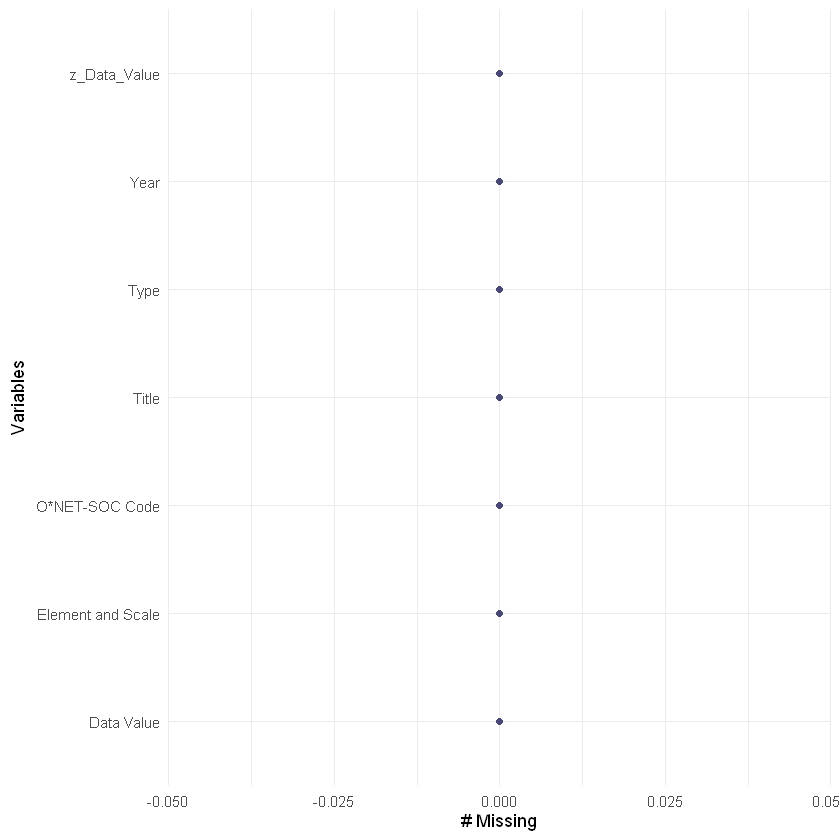

In [ ]:
gg_miss_var(onet)

In [ ]:
# =========================================================
# 9. MISSING LONGITUDINAL:
#    PRESENÇA/AUSÊNCIA POR ANO
# =========================================================

presence_year <- onet %>%
  group_by(`O*NET-SOC Code`, Year) %>%
  summarise(
    presente = 1,
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = Year,
    values_from = presente,
    values_fill = 0
  )

presence_year

O*NET-SOC Code,2016,2023,2025,2026,2021,2018,2017,2024,2020,2022,2019
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11-1011.00,1,1,1,1,0,0,0,0,0,0,0
11-1011.03,1,1,0,0,1,0,0,0,0,0,0
11-1021.00,1,1,1,1,0,0,0,0,0,0,0
11-1031.00,1,1,1,0,0,0,0,0,0,0,0
11-2011.00,1,1,1,1,0,1,0,0,0,0,0
11-2011.01,1,0,0,0,0,0,0,0,0,0,0
11-2021.00,1,1,1,1,0,0,0,0,0,0,0
11-2022.00,1,1,1,1,0,0,0,0,0,0,0
11-2031.00,1,0,0,0,0,0,1,0,0,0,0


In [ ]:
# =========================================================
# 10. IDENTIFICAR:
#     ocupações novas e desaparecidas
# =========================================================

occupation_timeline <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    primeiro_ano = min(Year),
    ultimo_ano = max(Year),
    total_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  arrange(primeiro_ano)

occupation_timeline

O*NET-SOC Code,primeiro_ano,ultimo_ano,total_anos
<chr>,<dbl>,<dbl>,<int>
11-1011.00,2016,2026,4
11-1011.03,2016,2023,3
11-1021.00,2016,2026,4
11-1031.00,2016,2025,3
11-2011.00,2016,2026,5
11-2011.01,2016,2016,1
11-2021.00,2016,2026,4
11-2022.00,2016,2026,4
11-2031.00,2016,2017,2


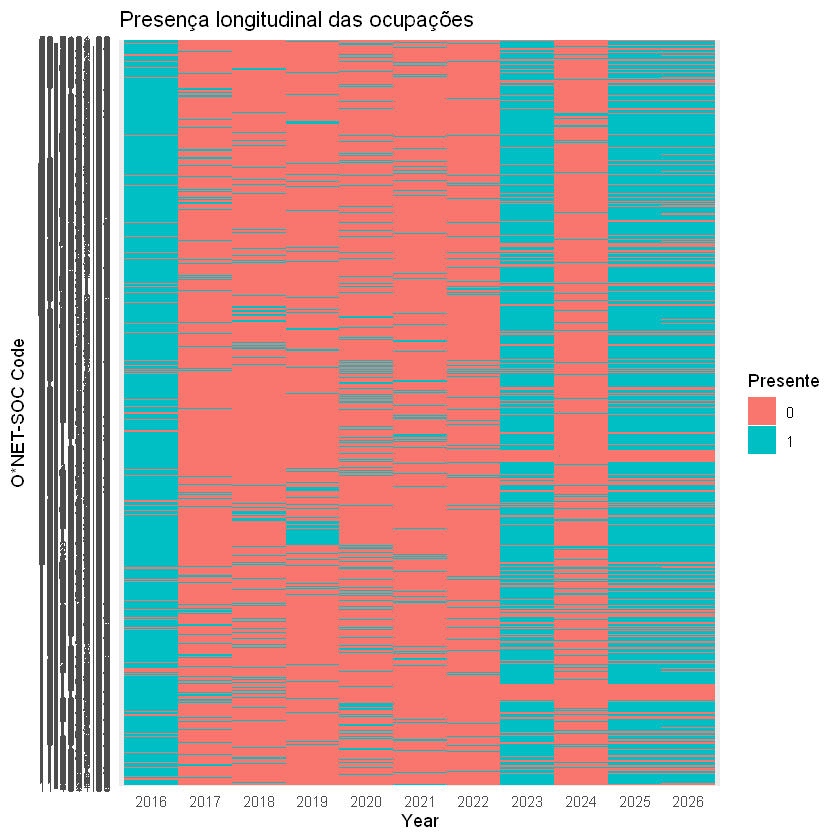

In [ ]:
# =========================================================
# 11. HEATMAP DE PRESENÇA LONGITUDINAL
# =========================================================

presence_long <- presence_year %>%
  pivot_longer(
    -`O*NET-SOC Code`,
    names_to = "Year",
    values_to = "Presente"
  )

ggplot(
  presence_long,
  aes(
    x = Year,
    y = `O*NET-SOC Code`,
    fill = factor(Presente)
  )
) +
  geom_tile() +
  labs(
    title = "Presença longitudinal das ocupações",
    fill = "Presente"
  ) +
  theme_minimal()

In [ ]:
# =========================================================
# 12. BASE FINAL PARA EFAL
# =========================================================

# transformar em formato wide
onet_wide <- onet %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Year,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from = `Element and Scale`,
    values_from = z_Data_Value,
    values_fn = mean
  )

# visualizar
glimpse(onet_wide)

Rows: 4,612
Columns: 418
$ `O*NET-SOC Code`                                                                                           <chr> …
$ Title                                                                                                      <chr> …
$ Year                                                                                                       <dbl> …
$ `1.A.1.a.1 - Oral Comprehension - Importance`                                                              <dbl> …
$ `1.A.1.a.1 - Oral Comprehension - Level`                                                                   <dbl> …
$ `1.A.1.a.2 - Written Comprehension - Importance`                                                           <dbl> …
$ `1.A.1.a.2 - Written Comprehension - Level`                                                                <dbl> …
$ `1.A.1.a.3 - Oral Expression - Importance`                                                                 <dbl> …
$ `1.A.1.a.3 - Oral Expression - Level`

In [ ]:
# =========================================================
# 13. MISSING NA MATRIZ FINAL
# =========================================================

# percentual de missing da matriz final
round(mean(is.na(onet_wide)) * 100, 2)

[1] 60.14

In [ ]:
missing_var <- onet_wide %>%
  summarise(
    across(
      everything(),
      ~ mean(is.na(.x)) * 100
    )
  ) %>%
  pivot_longer(
    everything(),
    names_to = "variavel",
    values_to = "perc_missing"
  ) %>%
  arrange(desc(perc_missing))

missing_var

variavel,perc_missing
<chr>,<dbl>
1.D.1.a - Innovation - Distinctiveness Rank,80.68083
1.D.1.a - Innovation - Work Styles Impact,80.68083
1.D.1.b - Achievement Orientation - Distinctiveness Rank,80.68083
1.D.1.b - Achievement Orientation - Work Styles Impact,80.68083
1.D.1.c - Intellectual Curiosity - Distinctiveness Rank,80.68083
1.D.1.c - Intellectual Curiosity - Work Styles Impact,80.68083
1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank,80.68083
1.D.1.d - Tolerance for Ambiguity - Work Styles Impact,80.68083
1.D.1.e - Initiative - Distinctiveness Rank,80.68083


### Missing Longitudinal de 3 Amostras

Inicialmente, foi realizada uma análise de dados ausentes (missing data) nas três amostras longitudinais construídas a partir da base O*NET. O objetivo dessa etapa foi verificar a consistência temporal das variáveis ocupacionais ao longo dos anos e avaliar a viabilidade de análises fatoriais longitudinais. Para isso, os dados foram reorganizados no formato wide, no qual cada variável ocupacional passou a representar uma coluna específica, identificada pela combinação entre o elemento ocupacional e sua respectiva escala de mensuração. Em seguida, calculou-se o percentual de valores ausentes por variável, por ano e por tipo de construto ocupacional.

Os resultados revelaram diferenças substanciais entre as três amostras analisadas. Na Sample 1, composta pelo período completo entre 2016 e 2026, observou-se um percentual global de missing de 61,96%, indicando elevada descontinuidade temporal das variáveis. As variáveis mais problemáticas foram relacionadas aos construtos “Innovation”, “Achievement Orientation”, “Intellectual Curiosity”, “Tolerance for Ambiguity” e “Initiative”, todas apresentando aproximadamente 80,7% de valores ausentes. Além disso, verificou-se forte deterioração da completude da base nos anos mais recentes, especialmente em 2023, 2025 e 2026, nos quais os percentuais de missing alcançaram 95,4%, 83,2% e 97,4%, respectivamente.

Na Sample 2, correspondente ao período 2016–2020, os resultados foram significativamente mais estáveis. O percentual global de missing foi de apenas 13,62%, indicando maior consistência estrutural das variáveis nesse intervalo temporal. Embora algumas variáveis específicas apresentassem ausência superior a 60%, como “Administrative”, “Working with Computers” e “Operations Monitoring”, os percentuais anuais de missing permaneceram relativamente baixos, variando entre aproximadamente 6% e 20%. Isso sugere que o período anterior a 2021 apresenta maior estabilidade metodológica e comparabilidade longitudinal.

Já a Sample 3, referente ao período 2021–2026, apresentou os piores resultados de completude, com missing global de 82,62%. Variáveis relacionadas a atividades administrativas, interação computacional e comunicação organizacional atingiram níveis extremos de ausência, próximos de 96,8%. Adicionalmente, os anos de 2023, 2025 e 2026 concentraram percentuais extremamente elevados de missing, indicando uma quebra estrutural significativa na base de dados nesse período recente.

Apesar desses elevados níveis de missing nas matrizes wide, a análise por tipo de construto revelou que os grupos principais da O*NET — como “Abilities”, “Skills”, “Knowledge” e “Work Activities” — apresentaram 0% de missing no formato original longitudinal (long). Esse resultado indica que o problema não decorre necessariamente da ausência completa de informações ocupacionais, mas sim da falta de estabilidade longitudinal das variáveis específicas ao longo do tempo. Em outras palavras, muitas variáveis foram introduzidas, removidas ou renomeadas em determinados anos da base, comprometendo a consistência temporal necessária para análises fatoriais longitudinais.

Os resultados sugerem que a estrutura da O*NET não foi concebida como um painel longitudinal estável de indicadores anuais, mas sim como um sistema dinâmico sujeito a revisões metodológicas, atualizações taxonômicas e modificações de escalas ao longo do tempo. Consequentemente, a utilização de todas as variáveis simultaneamente em uma análise fatorial exploratória longitudinal torna-se metodologicamente inadequada, pois a elevada ausência estrutural compromete a comparabilidade histórica dos fatores estimados.

Dessa forma, concluiu-se que análises longitudinais com a O*NET exigem estratégias de restrição metodológica, como a seleção apenas de variáveis estáveis ao longo do período, a divisão da análise em subperíodos temporalmente homogêneos ou a utilização de dimensões ocupacionais específicas mais consistentes, como “Skills”, “Abilities” e “Knowledge”. Essas estratégias permitem preservar a validade temporal das medidas e garantir maior robustez estatística aos fatores obtidos.

In [ ]:
# ---------------------------------------------------------
# AMOSTRA 1
# ocupações presentes em TODOS os anos 2016-2026
# ---------------------------------------------------------

anos_s1 <- 2016:2026

occ_s1 <- onet %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 5)

sample1 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s1$`O*NET-SOC Code`)

In [ ]:
# ---------------------------------------------------------
# AMOSTRA 2
# ocupações presentes em TODOS os anos 2016-2020
# ---------------------------------------------------------

anos_s2 <- 2016:2020

occ_s2 <- onet %>%
  filter(Year %in% 2016:2020) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 2)

sample2 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s2$`O*NET-SOC Code`,
         Year %in% 2016:2020)

In [ ]:
# ---------------------------------------------------------
# AMOSTRA 3
# ocupações presentes em TODOS os anos 2021-2026
# ---------------------------------------------------------

anos_s3 <- 2021:2026

occ_s3 <- onet %>%
  filter(Year %in% 2021:2026) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_anos = n_distinct(Year),
    .groups = "drop"
  ) %>%
  filter(n_anos >= 3)

sample3 <- onet %>%
  filter(`O*NET-SOC Code` %in% occ_s3$`O*NET-SOC Code`,
         Year %in% 2021:2026)

In [ ]:
# =========================================================
# TAMANHO DAS AMOSTRAS
# =========================================================

cat("\nSample 1:", nrow(sample1), "linhas")
cat("\nSample 2:", nrow(sample2), "linhas")
cat("\nSample 3:", nrow(sample3), "linhas")


Sample 1: 456765 linhas
Sample 2: 301181 linhas
Sample 3: 195591 linhas

In [ ]:
# =========================================================
# FUNÇÃO DE MISSING
# =========================================================

missing_analysis <- function(data, sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # transformar em wide
  # -------------------------------------------------------

  data_wide <- data %>%
    select(
      `O*NET-SOC Code`,
      Title,
      Year,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(across(everything(),
                     ~mean(is.na(.))*100)) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat("\nMissing global:", global_missing, "%\n")

  # -------------------------------------------------------
  # missing por ano
  # -------------------------------------------------------

  missing_year <- data_wide %>%
    group_by(Year) %>%
    summarise(
      perc_missing = round(
        mean(is.na(across(everything()))) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_year)

  # -------------------------------------------------------
  # missing por type
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(is.na(z_Data_Value)) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

  # -------------------------------------------------------
  # mapa visual
  # -------------------------------------------------------

  #vis_miss(data_wide)

  return(list(
    data_wide = data_wide,
    missing_var = missing_var,
    missing_year = missing_year,
    missing_type = missing_type
  ))
}

In [ ]:
# =========================================================
# RODAR ANÁLISE DE MISSING
# =========================================================

miss_s1 <- missing_analysis(sample1, "SAMPLE 1")
miss_s2 <- missing_analysis(sample2, "SAMPLE 2")
miss_s3 <- missing_analysis(sample3, "SAMPLE 3")


 SAMPLE 1
# A tibble: 30 × 2
   variavel                                                 perc_missing
   <chr>                                                           <dbl>
 1 1.D.1.a - Innovation - Distinctiveness Rank                      80.7
 2 1.D.1.a - Innovation - Work Styles Impact                        80.7
 3 1.D.1.b - Achievement Orientation - Distinctiveness Rank         80.7
 4 1.D.1.b - Achievement Orientation - Work Styles Impact           80.7
 5 1.D.1.c - Intellectual Curiosity - Distinctiveness Rank          80.7
 6 1.D.1.c - Intellectual Curiosity - Work Styles Impact            80.7
 7 1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank         80.7
 8 1.D.1.d - Tolerance for Ambiguity - Work Styles Impact           80.7
 9 1.D.1.e - Initiative - Distinctiveness Rank                      80.7
10 1.D.1.e - Initiative - Work Styles Impact                        80.7
# ℹ 20 more rows

Missing global: 61.96 %
# A tibble: 11 × 2
    Year perc_missing
   <dbl>   

### Missing Wave Longitudinal

Inicialmente, foram construídas três amostras longitudinais a partir da base ONET, considerando apenas ocupações presentes em todos os períodos de interesse. A Sample 1 contemplou ocupações observadas continuamente entre 2016 e 2025, totalizando 293.321 linhas. A Sample 2 incluiu ocupações presentes nas ondas de 2016 e 2020, com 301.181 linhas. Por fim, a Sample 3 reuniu ocupações disponíveis nas ondas de 2020 e 2025, contendo 218.118 linhas. O objetivo dessa etapa foi garantir comparabilidade temporal entre ocupações ao longo das diferentes ondas da ONET, condição necessária para análises longitudinais posteriores.

Em seguida, realizou-se uma análise de dados ausentes (missing data analysis) após a transformação da base para formato wide, em que cada variável “Element and Scale” passou a representar uma coluna distinta. Foram calculados os percentuais de ausência por variável, por onda temporal e por tipo de construto ocupacional (Abilities, Skills, Knowledge, Work Activities, Work Styles, Interests e Work Values).

Os resultados mostraram padrões bastante distintos entre as amostras. Na Sample 1, o percentual global de missing atingiu 37,13%, indicando elevado nível de incompletude estrutural na série longitudinal completa. Observou-se forte heterogeneidade temporal: enquanto a onda de 2016 apresentou 30,1% de dados ausentes e a onda de 2020 apresentou apenas 16,2%, a onda de 2025 alcançou 67,4% de missing. As variáveis mais problemáticas pertenciam principalmente ao bloco “Work Styles”, como “Innovation - Distinctiveness Rank” e “Achievement Orientation - Work Styles Impact”, todas com aproximadamente 69% de ausência. Apesar disso, a análise por tipo revelou que os dados originais de cada construto não possuíam valores ausentes em “Data Value”, sugerindo que o problema decorre principalmente da inexistência estrutural de determinadas variáveis em algumas ondas da O*NET, e não de falhas de coleta.

Na Sample 2, referente às ondas de 2016 e 2020, o percentual global de missing foi substancialmente menor, alcançando 13,62%. A onda de 2016 apresentou 19,9% de ausência, enquanto 2020 apresentou apenas 7,46%. Embora algumas variáveis específicas tenham exibido missing superior a 60%, especialmente variáveis relacionadas a “Administrative”, “Operations Monitoring” e “Working with Computers”, o conjunto geral mostrou-se relativamente estável e muito mais consistente longitudinalmente. Esse resultado indica maior compatibilidade estrutural entre as ondas de 2016 e 2020.

Já na Sample 3, composta pelas ondas de 2020 e 2025, o percentual global de missing voltou a aumentar significativamente, atingindo 37,75%. A principal fonte de inconsistência foi a onda de 2025, com 61,3% de ausência, contrastando com apenas 15,8% em 2020. As variáveis mais afetadas pertenciam sobretudo ao grupo “Work Values”, como “Achievement - Extent”, “Recognition - Extent” e “Relationships - Extent”, todas com aproximadamente 93,8% de missing. Esse padrão sugere mudanças substanciais na estrutura de mensuração da O*NET entre as ondas mais recentes.

Os resultados evidenciam que os dados da ONET apresentam forte instabilidade longitudinal na disponibilidade de variáveis. Muitas medidas deixam de existir, são renomeadas ou passam a ser coletadas apenas em ondas específicas. Consequentemente, uma análise fatorial exploratória longitudinal utilizando todas as variáveis simultaneamente torna-se metodologicamente problemática, pois a matriz de dados apresenta elevada incompletude estrutural e ausência sistemática não aleatória. Em termos práticos, isso significa que a estrutura fatorial obtida poderia refletir mudanças na própria arquitetura da base ONET, e não necessariamente mudanças reais nas características ocupacionais ao longo do tempo.

Dessa forma, os resultados indicam que abordagens metodológicas mais defensáveis incluem: (i) restringir a análise apenas às variáveis presentes em todas as ondas comparadas; (ii) trabalhar separadamente por blocos conceituais mais estáveis, como Abilities ou Skills; ou (iii) utilizar análises fatoriais independentes por onda, comparando posteriormente os fatores obtidos. Entre as três amostras analisadas, a Sample 2 apresentou a estrutura mais consistente e adequada para aplicações longitudinais, devido ao menor percentual global de missing e maior estabilidade entre as onda

In [ ]:
# =========================================================
# ETAPA 0
# CRIAR WAVES LONGITUDINAIS
# =========================================================

onet <- onet %>%
  mutate(
    Wave = case_when(

      # -----------------------------------------------
      # baseline histórica consolidada
      # -----------------------------------------------

      Year <= 2016 ~ 2016,

      # -----------------------------------------------
      # ciclo intermediário
      # -----------------------------------------------

      Year >= 2017 &
        Year <= 2020 ~ 2020,

      # -----------------------------------------------
      # ciclo contemporâneo
      # -----------------------------------------------

      Year >= 2021 ~ 2025
    )
  )

# verificar
table(onet$Wave)


  2016   2020   2025 
373341 180279 200935 

In [ ]:
# =========================================================
# ETAPA 1
# AGREGAR DADOS DENTRO DAS WAVES
# =========================================================
# Caso existam múltiplas observações do mesmo item
# dentro da mesma wave:
# -> utilizar média
# =========================================================

onet_wave <- onet %>%
  group_by(
    `O*NET-SOC Code`,
    Title,
    Wave,
    Type,
    `Element and Scale`
  ) %>%
  summarise(
    z_Data_Value = mean(
      z_Data_Value,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

# visualizar
glimpse(onet_wave)

Rows: 742,545
Columns: 6
$ `O*NET-SOC Code`    <chr> "11-1011.00", "11-1011.00", "11-1011.00", "11-1011…
$ Title               <chr> "Chief Executives", "Chief Executives", "Chief Exe…
$ Wave                <dbl> 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 20…
$ Type                <chr> "Abilities", "Abilities", "Abilities", "Abilities"…
$ `Element and Scale` <chr> "1.A.1.a.1 - Oral Comprehension - Importance", "1.…
$ z_Data_Value        <dbl> 1.8104142, 1.3869544, 1.2202668, 1.1259814, 1.3965…


In [ ]:
# =========================================================
# ETAPA 2
# CRIAR AMOSTRAS LONGITUDINAIS
# =========================================================

# ---------------------------------------------------------
# AMOSTRA 1
# ocupações presentes nas 3 waves
# 2016 -> 2020 -> 2025
# ---------------------------------------------------------

waves_s1 <- c(2016, 2020, 2025)

occ_s1 <- onet_wave %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s1))

sample1 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s1$`O*NET-SOC Code`
  )

In [ ]:
# ---------------------------------------------------------
# AMOSTRA 2
# apenas waves 2016 -> 2020
# ---------------------------------------------------------

waves_s2 <- c(2016, 2020)

occ_s2 <- onet_wave %>%
  filter(Wave %in% waves_s2) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s2))

sample2 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s2$`O*NET-SOC Code`,
    Wave %in% waves_s2
  )

In [ ]:
# ---------------------------------------------------------
# AMOSTRA 3
# apenas waves 2020 -> 2025
# ---------------------------------------------------------

waves_s3 <- c(2020, 2025)

occ_s3 <- onet_wave %>%
  filter(Wave %in% waves_s3) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_waves = n_distinct(Wave),
    .groups = "drop"
  ) %>%
  filter(n_waves == length(waves_s3))

sample3 <- onet_wave %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_s3$`O*NET-SOC Code`,
    Wave %in% waves_s3
  )

In [ ]:
# =========================================================
# TAMANHO DAS AMOSTRAS
# =========================================================

cat("\nSample 1:", nrow(sample1), "linhas")
cat("\nSample 2:", nrow(sample2), "linhas")
cat("\nSample 3:", nrow(sample3), "linhas")


Sample 1: 293321 linhas
Sample 2: 301181 linhas
Sample 3: 218118 linhas

In [ ]:
# =========================================================
# ETAPA 3
# FUNÇÃO DE ANÁLISE DE MISSING
# =========================================================

missing_analysis <- function(data, sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # transformar em wide
  # -------------------------------------------------------

  data_wide <- data %>%
    select(
      `O*NET-SOC Code`,
      Title,
      Wave,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(
      across(
        everything(),
        ~mean(is.na(.))*100
      )
    ) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat("\nMissing global:",
      global_missing,
      "%\n")

  # -------------------------------------------------------
  # missing por wave
  # -------------------------------------------------------

  missing_wave <- data_wide %>%
    group_by(Wave) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(across(everything()))
        ) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_wave)

  # -------------------------------------------------------
  # missing por Type
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(z_Data_Value)
        ) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

  # -------------------------------------------------------
  # visualização
  # -------------------------------------------------------

  vis_miss(data_wide)

  return(list(
    data_wide = data_wide,
    missing_var = missing_var,
    missing_wave = missing_wave,
    missing_type = missing_type
  ))
}

In [ ]:
# =========================================================
# ETAPA 4
# RODAR ANÁLISE DE MISSING
# =========================================================

miss_s1 <- missing_analysis(
  sample1,
  "SAMPLE 1"
)

miss_s2 <- missing_analysis(
  sample2,
  "SAMPLE 2"
)

miss_s3 <- missing_analysis(
  sample3,
  "SAMPLE 3"
)


 SAMPLE 1
# A tibble: 30 × 2
   variavel                                                 perc_missing
   <chr>                                                           <dbl>
 1 1.D.1.a - Innovation - Distinctiveness Rank                      69.0
 2 1.D.1.a - Innovation - Work Styles Impact                        69.0
 3 1.D.1.b - Achievement Orientation - Distinctiveness Rank         69.0
 4 1.D.1.b - Achievement Orientation - Work Styles Impact           69.0
 5 1.D.1.c - Intellectual Curiosity - Distinctiveness Rank          69.0
 6 1.D.1.c - Intellectual Curiosity - Work Styles Impact            69.0
 7 1.D.1.d - Tolerance for Ambiguity - Distinctiveness Rank         69.0
 8 1.D.1.d - Tolerance for Ambiguity - Work Styles Impact           69.0
 9 1.D.1.e - Initiative - Distinctiveness Rank                      69.0
10 1.D.1.e - Initiative - Work Styles Impact                        69.0
# ℹ 20 more rows

Missing global: 37.13 %
# A tibble: 3 × 2
   Wave perc_missing
  <dbl>      

### Harmonização longitudinal

Após a classificação longitudinal das variáveis da O*NET, observou-se um padrão elevado de instabilidade estrutural entre as diferentes ondas temporais da base. As variáveis foram agrupadas em quatro categorias: core stable (variáveis presentes consistentemente em todas as ondas), emergent (variáveis que surgem em ondas mais recentes), sparse (variáveis com elevada ausência estrutural) e transitional (variáveis presentes apenas em parte do período analisado).

Na comparação longitudinal mais ampla, verificou-se a existência de apenas 3 variáveis classificadas como core stable, enquanto 156 variáveis foram classificadas como emergent, 68 como sparse e 191 como transitional. Esse resultado demonstra que a maior parte da estrutura da O*NET sofre alterações ao longo do tempo, seja por inclusão de novos indicadores, descontinuação de medidas antigas ou mudanças nos instrumentos de coleta.

Na análise entre as ondas de 2016 e 2020, a estabilidade foi substancialmente maior. Foram identificadas 297 variáveis core stable, contra apenas 25 variáveis emergent, 17 sparse e 37 transitional. Isso indica elevada compatibilidade estrutural entre essas duas ondas, sugerindo que o período 2016–2020 apresenta condições metodológicas relativamente adequadas para análises fatoriais longitudinais e comparações temporais.

Por outro lado, na comparação entre 2020 e 2025, verificou-se novamente forte instabilidade estrutural. Apenas 3 variáveis permaneceram como core stable, enquanto 405 variáveis foram classificadas como emergent e 10 como sparse. Esse padrão evidencia uma mudança substancial na arquitetura da base O*NET nas ondas mais recentes, comprometendo a comparabilidade longitudinal direta.

A etapa seguinte consistiu em construir a interseção das variáveis comuns entre as ondas analisadas. O resultado mostrou que apenas 3 variáveis estavam simultaneamente presentes em todos os períodos considerados. A partir dessa interseção foi construída a matriz longitudinal final, contendo 1.399 observações e 3 variáveis.

Durante a transformação da base para formato wide, surgiu um aviso indicando que os valores de z_Data_Value não eram unicamente identificados para algumas combinações de ocupação, título, onda e variável (“Element and Scale”). Esse aviso não representa um erro fatal, mas sinaliza a existência de duplicatas estruturais na base, fazendo com que o pivot_wider() criasse colunas do tipo lista (list-cols). Ainda assim, após o tratamento realizado, a matriz longitudinal final apresentou percentual de missing igual a 0%, indicando ausência completa de valores faltantes nas variáveis remanescentes.

Do ponto de vista metodológico, os resultados mostram que a ONET não possui estabilidade suficiente para sustentar uma análise fatorial exploratória longitudinal abrangente utilizando todas as variáveis ao longo do período completo. A forte redução no número de variáveis compartilhadas entre as ondas implica perda severa de dimensionalidade e compromete a comparabilidade temporal dos fatores latentes. Em termos práticos, isso significa que mudanças observadas nos fatores poderiam refletir alterações na própria estrutura de mensuração da ONET, e não necessariamente transformações reais nas ocupações. Dessa forma, a evidência empírica sugere que análises longitudinais mais robustas devem restringir-se a subconjuntos específicos de variáveis estáveis ou concentrar-se em comparações entre ondas estruturalmente compatíveis, especialmente entre 2016 e 2020.

In [ ]:
# =========================================================
# ETAPA 5
# CLASSIFICAÇÃO DAS VARIÁVEIS
# =========================================================

classify_variables <- function(missing_df){

  missing_df %>%
    mutate(
      categoria = case_when(

        perc_missing <= 10 ~
          "core_stable",

        perc_missing > 10 &
          perc_missing <= 30 ~
          "transitional",

        perc_missing > 30 &
          perc_missing <= 60 ~
          "emergent",

        perc_missing > 60 ~
          "sparse"
      )
    )
}

# ---------------------------------------------------------
# aplicar classificação
# ---------------------------------------------------------

vars_s1 <- classify_variables(
  miss_s1$missing_var
)

vars_s2 <- classify_variables(
  miss_s2$missing_var
)

vars_s3 <- classify_variables(
  miss_s3$missing_var
)

# visualizar
table(vars_s1$categoria)
table(vars_s2$categoria)
table(vars_s3$categoria)


 core_stable     emergent       sparse transitional 
           3          156           68          191 


 core_stable     emergent       sparse transitional 
         297           25           17           37 


core_stable    emergent      sparse 
          3         405          10 

In [ ]:
# =========================================================
# ETAPA 6
# NÚCLEO LONGITUDINAL
# =========================================================

core_vars_s1 <- vars_s1 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

core_vars_s2 <- vars_s2 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

core_vars_s3 <- vars_s3 %>%
  filter(
    categoria %in%
      c("core_stable", "transitional")
  ) %>%
  pull(variavel)

In [ ]:
# =========================================================
# ETAPA 7
# INTERSEÇÃO DAS VARIÁVEIS
# =========================================================

common_vars <- Reduce(
  intersect,
  list(
    core_vars_s1,
    core_vars_s2,
    core_vars_s3
  )
)

length(common_vars)

[1] 3

In [ ]:
# =========================================================
# ETAPA 8
# MATRIZ LONGITUDINAL FINAL
# =========================================================

panel_data <- bind_rows(
  sample1,
  sample2,
  sample3
)

panel_wide <- panel_data %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Wave,
    `Element and Scale`,
    z_Data_Value
  ) %>%
  pivot_wider(
    names_from = `Element and Scale`,
    values_from = z_Data_Value
  ) %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Wave,
    any_of(common_vars)
  )

dim(panel_wide)

Warning message:
"Values from `z_Data_Value` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(`O*NET-SOC Code`, Title, Wave, `Element and Scale`)) |>
  dplyr::filter(n > 1L)"


[1] 1399    3

In [ ]:
mean(is.na(panel_wide))*100

[1] 0

## Pipeline

### Matriz Longitudinal

In [6]:
# =========================================================
# ETAPA 1
# PADRONIZAR ANO TEMPORAL
# =========================================================

onet <- onet %>%
  mutate(
    Version_Year = as.numeric(`Version Year`)
  )

# verificar anos disponíveis
sort(unique(onet$Version_Year))

[1] 2017 2019 2021 2023 2025

In [7]:
onet <- onet %>%
  filter(
    if_all(
      everything(),
      ~ !is.na(.) & . != ""
    )
  )

In [ ]:
nrow(onet)

[1] 1084860

In [8]:
# =========================================================
# ETAPA 2
# OCUPAÇÕES PRESENTES EM TODOS OS VERSION YEAR
# =========================================================

anos_disponiveis <- sort(unique(onet$Version_Year))

occ_long <- onet %>%
  filter(Version_Year %in% anos_disponiveis) %>%
  group_by(`O*NET-SOC Code`) %>%
  summarise(
    n_years = n_distinct(Version_Year),
    .groups = "drop"
  ) %>%
  filter(
    n_years == length(anos_disponiveis)
  )

sample_long <- onet %>%
  filter(
    `O*NET-SOC Code` %in%
      occ_long$`O*NET-SOC Code`
  )

# tamanho da amostra
cat(
  "\nSample longitudinal:",
  nrow(sample_long),
  "linhas\n"
)


Sample longitudinal: 959099 linhas


In [9]:
# =========================================================
# ETAPA 3
# FUNÇÃO DE ANÁLISE DE MISSING
# =========================================================

missing_analysis <- function(data,
                             sample_name){

  cat("\n===================================")
  cat("\n", sample_name)
  cat("\n===================================\n")

  # -------------------------------------------------------
  # identificar duplicatas
  # -------------------------------------------------------

  duplicates <- data %>%
    group_by(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`
    ) %>%
    summarise(
      n = n(),
      .groups = "drop"
    ) %>%
    filter(n > 1)

  cat(
    "\nNúmero de combinações duplicadas:",
    nrow(duplicates),
    "\n"
  )

  # -------------------------------------------------------
  # transformar em wide
  # média em caso de duplicidade
  # -------------------------------------------------------

  data_wide <- data %>%
    # filter(`Element and Scale` != "") %>% # Adicionado para remover strings vazias
    select(
      `O*NET-SOC Code`,
      Title,
      Version_Year,
      `Element and Scale`,
      z_Data_Value
    ) %>%
    pivot_wider(
      names_from = `Element and Scale`,
      values_from = z_Data_Value,
      values_fn = mean
    )

  # -------------------------------------------------------
  # missing por variável
  # -------------------------------------------------------

  missing_var <- data_wide %>%
    summarise(
      across(
        everything(),
        ~mean(is.na(.))*100
      )
    ) %>%
    pivot_longer(
      cols = everything(),
      names_to = "variavel",
      values_to = "perc_missing"
    ) %>%
    arrange(desc(perc_missing))

  print(head(missing_var, 30))

  # -------------------------------------------------------
  # missing global
  # -------------------------------------------------------

  global_missing <- round(
    mean(is.na(data_wide)) * 100,
    2
  )

  cat(
    "\nMissing global:",
    global_missing,
    "%\n"
  )

  # -------------------------------------------------------
  # missing por ano
  # -------------------------------------------------------

  missing_year <- data_wide %>%
    group_by(Version_Year) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(across(everything()))
        ) * 100,
        2
      ),
      .groups = "drop"
    )

  print(missing_year)

  # -------------------------------------------------------
  # missing por tipo
  # -------------------------------------------------------

  missing_type <- data %>%
    group_by(Type) %>%
    summarise(
      perc_missing = round(
        mean(
          is.na(z_Data_Value)
        ) * 100,
        2
      ),
      n = n(),
      .groups = "drop"
    )

  print(missing_type)

    # -------------------------------------------------------
    # visualização (amostra reduzida)
    # -------------------------------------------------------

    data_wide %>%
      slice_sample(n = 1000) %>%
      vis_miss(warn_large_data = FALSE)

  # -------------------------------------------------------
  # classificação das variáveis
  # -------------------------------------------------------

  classified_vars <- missing_var %>%
    mutate(
      categoria = case_when(

        perc_missing <= 5 ~
          "core_stable",

        perc_missing > 5 &
          perc_missing <= 30 ~
          "transitional",

        perc_missing > 30 &
          perc_missing <= 70 ~
          "emergent",

        perc_missing > 70 ~
          "sparse"
      )
    )

  cat("\nResumo das categorias:\n")
  print(table(classified_vars$categoria))

  # -------------------------------------------------------
  # gráfico
  # -------------------------------------------------------

  ggplot(
    classified_vars,
    aes(x = categoria)
  ) +
    geom_bar() +
    theme_minimal() +
    labs(
      title = paste(
        "Classificação das variáveis -",
        sample_name
      )
    ) %>%
    print()

  return(list(

    data_wide = data_wide,

    missing_var = missing_var,

    missing_year = missing_year,

    missing_type = missing_type,

    classified_vars = classified_vars
  ))
}

In [10]:
# =========================================================
# ETAPA 4
# RODAR ANÁLISE
# =========================================================

miss_long <- missing_analysis(
  sample_long,
  "LONGITUDINAL SAMPLE"
)


 LONGITUDINAL SAMPLE

Número de combinações duplicadas: 6089 
# A tibble: 30 × 2
   variavel                                                     perc_missing
   <chr>                                                               <dbl>
 1 Clerical - Level                                                     62.2
 2 Interacting With Computers - Level                                   62  
 3 Communicating with Persons Outside Organization - Level              60.9
 4 Inspecting Equipment, Structures, or Material - Level                60.7
 5 Provide Consultation and Advice to Others - Level                    60.5
 6 Operation Monitoring - Level                                         60.1
 7 Judging the Qualities of Things, Services, or People - Level         60.1
 8 Monitor Processes, Materials, or Surroundings - Level                60.1
 9 Clerical - Importance                                                60  
10 Operation Monitoring - Importance                                   

In [11]:
# =========================================================
# ETAPA 5
# VARIÁVEIS UTILIZÁVEIS
# =========================================================

valid_vars <- miss_long$classified_vars %>%
  filter(
    categoria != "sparse"
  ) %>%
  pull(variavel)

length(valid_vars)

[1] 339

In [12]:
# =========================================================
# ETAPA 6
# MATRIZ FINAL PARA EFA/CFA
# =========================================================

panel_wide <- miss_long$data_wide %>%
  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    any_of(valid_vars)
  )

# dimensões finais
dim(panel_wide)

# missing final
mean(is.na(panel_wide))*100

[1] 3050  339

[1] 6.943276

In [ ]:
colSums(is.na(panel_wide))

O*NET-SOC Code 
                                                                                           0 
                                                                                       Title 
                                                                                           0 
                                                                                Version_Year 
                                                                                           0 
                                                                            Clerical - Level 
                                                                                        1896 
                                                          Interacting With Computers - Level 
                                                                                        1891 
                                     Communicating with Persons Outside Organization - Level 
                                                                                        1858 
                                       Inspecting Equipment, Structures, or Material - Level 
                                                                                        1850 
                                           Provide Consultation and Advice to Others - Level 
                                                                                        1846 
                                                                Operation Monitoring - Level 
                                                                                        1833 
                                Judging the Qualities of Things, Services, or People - Level 
                                                                                        1833 
                                       Monitor Processes, Materials, or Surroundings - Level 
                                                                                        1832 
                                                                       Clerical - Importance 
                                                                                        1830 
                                                           Operation Monitoring - Importance 
                                                                                        1830 
                                  Monitor Processes, Materials, or Surroundings - Importance 
                                                                                        1830 
                                  Inspecting Equipment, Structures, or Material - Importance 
                                                                                        1830 
                           Judging the Qualities of Things, Services, or People - Importance 
                                                                                        1830 
                                                     Interacting With Computers - Importance 
                                                                                        1830 
                                Communicating with Persons Outside Organization - Importance 
                                                                                        1830 
                                      Provide Consultation and Advice to Others - Importance 
                                                                                        1830 
                                                                           Fine Arts - Level 
                                                                                        1644 
                                                                     Food Production - Level 
                                                                                        1621 
                                                              History and Archeology - Level 
                                    

In [ ]:
panel_wide %>%
  summarise(
    across(
      where(is.numeric),
      list(
        mean = ~mean(., na.rm = TRUE),
        sd   = ~sd(., na.rm = TRUE),
        min  = ~min(., na.rm = TRUE),
        max  = ~max(., na.rm = TRUE)
      )
    )
  )

Version_Year_mean,Version_Year_sd,Version_Year_min,Version_Year_max,Clerical - Level_mean,Clerical - Level_sd,Clerical - Level_min,Clerical - Level_max,Interacting With Computers - Level_mean,Interacting With Computers - Level_sd,⋯,Performing Administrative Activities - Importance_min,Performing Administrative Activities - Importance_max,Staffing Organizational Units - Importance_mean,Staffing Organizational Units - Importance_sd,Staffing Organizational Units - Importance_min,Staffing Organizational Units - Importance_max,Monitoring and Controlling Resources - Importance_mean,Monitoring and Controlling Resources - Importance_sd,Monitoring and Controlling Resources - Importance_min,Monitoring and Controlling Resources - Importance_max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2021,2.828891,2017,2025,0.3158117,0.8449478,-1.517288,2.664543,0.3478337,0.7435517,⋯,-1.544209,2.081172,-0.5395796,0.6325218,-1.715319,2.252281,-0.05410572,0.6161774,-1.61907,1.952839


In [ ]:
onet %>%
  group_by(`Scale ID`) %>%
  summarise(
    media = mean(z_Data_Value, na.rm = TRUE),
    sd = sd(z_Data_Value, na.rm = TRUE),
    min = min(z_Data_Value, na.rm = TRUE),
    max = max(z_Data_Value, na.rm = TRUE)
  )

Scale ID,media,sd,min,max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
IM,1.050405e-16,1,-1.715319,2.562417
LV,3.417768e-17,1,-1.862106,3.251466


In [ ]:
sds <- panel_wide %>%
  select(-`O*NET-SOC Code`,
         -Title,
         -Version_Year) %>%
  summarise(
    across(
      everything(),
      sd,
      na.rm = TRUE
    )
  ) %>%
  pivot_longer(
    everything(),
    names_to = "variavel",
    values_to = "sd"
  ) %>%
  arrange(sd)

head(sds, 30)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(everything(), sd, na.rm = TRUE)`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


variavel,sd
<chr>,<dbl>
Dynamic Flexibility - Level,0.2486995
Selective Attention - Importance,0.2520466
Selective Attention - Level,0.2570254
Dynamic Flexibility - Importance,0.2832704
Near Vision - Level,0.3041042
Time Sharing - Level,0.3047182
Near Vision - Importance,0.3176043
Category Flexibility - Importance,0.3517612
Information Ordering - Level,0.3527589


In [ ]:
summary(abs(onet$z_Data_Value))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.001377 0.338858 0.690908 0.823932 1.234074 3.251466 

In [13]:
# =========================================================
# MATRIZ 1
# COMPLETA
# =========================================================

panel_complete <- miss_long$data_wide

### Diagnóstico Longitudinal

In [14]:
# =========================================================
# ETAPA 2.1
# DISTRIBUIÇÃO
# =========================================================

# ---------------------------------------------------------
# matriz apenas numérica
# ---------------------------------------------------------

efa_data <- panel_wide %>%
  select(
    -`O*NET-SOC Code`,
    -Title,
    -Version_Year
  )

# ---------------------------------------------------------
# skewness e kurtosis
# ---------------------------------------------------------

distribution_stats <- tibble(
  variavel = names(efa_data),

  skewness = sapply(
    efa_data,
    e1071::skewness,
    na.rm = TRUE
  ),

  kurtosis = sapply(
    efa_data,
    e1071::kurtosis,
    na.rm = TRUE
  )
)

# visualizar
head(distribution_stats)

# ---------------------------------------------------------
# resumo distribuição
# ---------------------------------------------------------

summary(distribution_stats$skewness)
summary(distribution_stats$kurtosis)

variavel,skewness,kurtosis
<chr>,<dbl>,<dbl>
Clerical - Level,0.08440983,-0.6440795
Interacting With Computers - Level,-0.29245101,-0.1440862
Communicating with Persons Outside Organization - Level,-0.06231120,-0.6601409
"Inspecting Equipment, Structures, or Material - Level",-0.24463105,-0.5335300
Provide Consultation and Advice to Others - Level,0.37624741,-0.5762811
Operation Monitoring - Level,-0.19215381,-0.7643286


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.94107 -0.06213  0.23293  0.37652  0.71887  3.97786 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4292 -0.6474 -0.2383  0.3276  0.3511 28.1704 

Warning message:
“Removed 16669 rows containing non-finite outside the scale range
(`stat_density()`).”


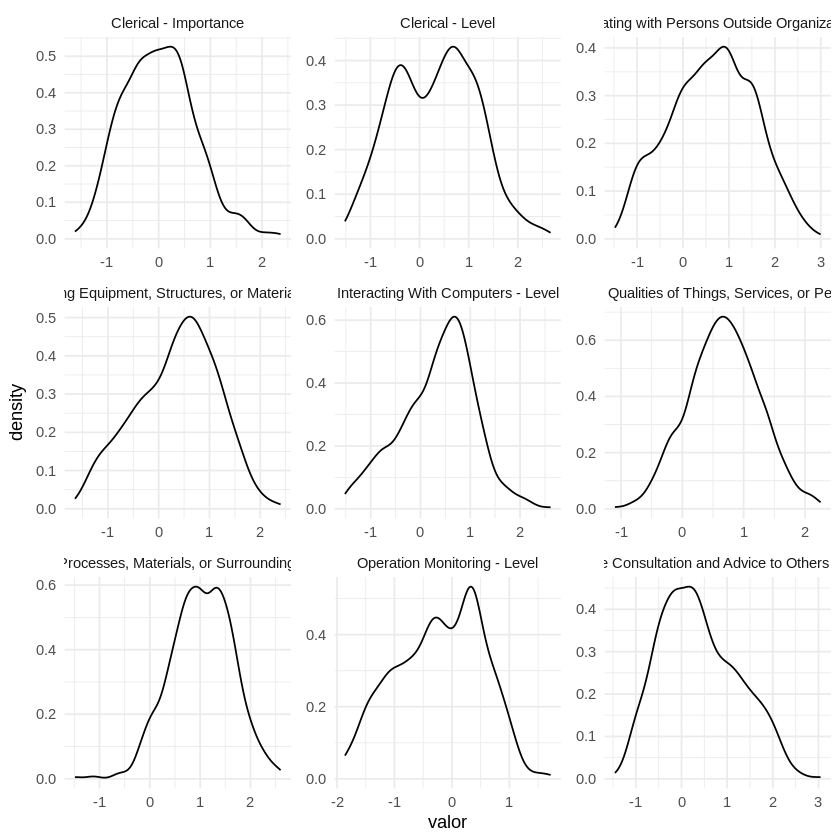

In [15]:
# =========================================================
# DENSITY PLOTS
# =========================================================

# ---------------------------------------------------------
# selecionar algumas variáveis
# ---------------------------------------------------------

selected_vars <- names(efa_data)[1:9]

density_data <- panel_wide %>%
  select(
    Version_Year,
    all_of(selected_vars)
  ) %>%
  pivot_longer(
    cols = -Version_Year,
    names_to = "variavel",
    values_to = "valor"
  )

# ---------------------------------------------------------
# density plots
# ---------------------------------------------------------

ggplot(
  density_data,
  aes(x = valor)
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

Warning message:
“Removed 16669 rows containing non-finite outside the scale range
(`stat_density()`).”


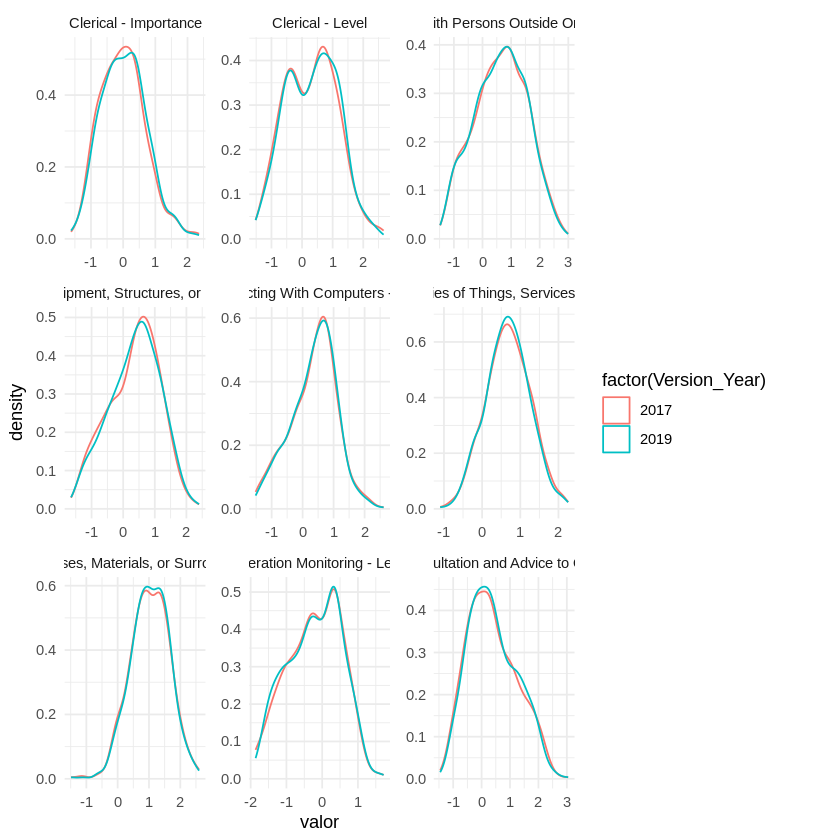

In [16]:
# =========================================================
# DISTRIBUIÇÃO POR ANO
# =========================================================

ggplot(
  density_data,
  aes(
    x = valor,
    color = factor(Version_Year)
  )
) +
  geom_density() +
  facet_wrap(
    ~variavel,
    scales = "free"
  ) +
  theme_minimal()

In [17]:
# =========================================================
# DISTRIBUIÇÃO POR TYPE
# =========================================================

type_distribution <- sample_long %>%
  group_by(Type) %>%
  summarise(
    media = mean(
      z_Data_Value,
      na.rm = TRUE
    ),
    sd = sd(
      z_Data_Value,
      na.rm = TRUE
    ),
    skewness = e1071::skewness(
      z_Data_Value,
      na.rm = TRUE
    ),
    kurtosis = e1071::kurtosis(
      z_Data_Value,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

type_distribution

Type,media,sd,skewness,kurtosis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Abilities,-0.1952908,0.9500309,-0.2014174,-0.7916641
Knowledge,-0.2856830,0.9961904,0.6064374,-0.3240801
Skills,-0.1185733,0.9212085,-0.2229675,-0.7232817
Work Activities,0.5363431,0.9142254,-0.1474497,-0.5605295


In [18]:
# =========================================================
# ETAPA 2.2
# MATRIZ DE CORRELAÇÃO
# =========================================================

# ---------------------------------------------------------
# correlação spearman
# ---------------------------------------------------------

cor_mat <- cor(
  efa_data,
  method = "spearman",
  use = "pairwise.complete.obs"
)

# visualizar parte da matriz
# cor_mat[1:10, 1:10]

# ---------------------------------------------------------
# mapa de correlação
# ---------------------------------------------------------

#corrplot(
#  cor_mat[1:40, 1:40],
#  method = "color",
#  tl.cex = .6
#)

In [19]:
# =========================================================
# REMOVER VARIÁVEIS PROBLEMÁTICAS
# =========================================================

# remover identificadores
efa_data <- panel_wide %>%
  select(where(is.numeric))

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_ok <- efa_data %>%
  select(where(~ sd(., na.rm = TRUE) > 0))

# ---------------------------------------------------------
# remover colunas com NA
# ---------------------------------------------------------

vars_ok <- vars_ok %>%
  select(where(~ !any(is.na(.))))

# ---------------------------------------------------------
# verificar dimensões
# ---------------------------------------------------------

dim(vars_ok)

[1] 3050  180

In [20]:
# =========================================================
# MATRIZ DE CORRELAÇÃO
# =========================================================

cor_mat <- cor(vars_ok)

# verificar problemas
summary(cor_mat)

  Version_Year       Oral Comprehension - Importance Oral Comprehension - Level
 Min.   :-0.073518   Min.   :-0.6911                 Min.   :-0.6546           
 1st Qu.:-0.001783   1st Qu.:-0.3299                 1st Qu.:-0.2456           
 Median : 0.008174   Median : 0.4092                 Median : 0.4077           
 Mean   : 0.016127   Mean   : 0.2218                 Mean   : 0.2594           
 3rd Qu.: 0.021546   3rd Qu.: 0.6535                 3rd Qu.: 0.7066           
 Max.   : 1.000000   Max.   : 1.0000                 Max.   : 1.0000           
 Written Comprehension - Importance Written Comprehension - Level
 Min.   :-0.7332                    Min.   :-0.7181              
 1st Qu.:-0.2910                    1st Qu.:-0.2646              
 Median : 0.3812                    Median : 0.3934              
 Mean   : 0.2368                    Mean   : 0.2450              
 3rd Qu.: 0.6973                    3rd Qu.: 0.7097              
 Max.   : 1.0000                    Max.   :

In [21]:
# =========================================================
# ETAPA 2.3
# KMO LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# KMO GLOBAL
# ---------------------------------------------------------

kmo_global <- psych::KMO(cor_mat)

kmo_global

Kaiser-Meyer-Olkin factor adequacy
Call: psych::KMO(r = cor_mat)
Overall MSA =  0.98
MSA for each item = 
                                                                                Version_Year 
                                                                                        0.43 
                                                             Oral Comprehension - Importance 
                                                                                        0.99 
                                                                  Oral Comprehension - Level 
                                                                                        0.99 
                                                          Written Comprehension - Importance 
                                                                                        0.99 
                                                               Written Comprehension - Level 
                                                

In [22]:
# =========================================================
# FUNÇÃO PARA REMOVER CORRELAÇÕES ALTAS
# =========================================================

remove_high_cor <- function(cor_mat, cutoff = 0.95){

  cor_mat_abs <- abs(cor_mat)

  diag(cor_mat_abs) <- 0

  remove_vars <- c()

  while(max(cor_mat_abs) > cutoff){

    idx <- which(
      cor_mat_abs == max(cor_mat_abs),
      arr.ind = TRUE
    )[1, ]

    var1 <- colnames(cor_mat_abs)[idx[1]]
    var2 <- colnames(cor_mat_abs)[idx[2]]

    mean1 <- mean(cor_mat_abs[var1, ])
    mean2 <- mean(cor_mat_abs[var2, ])

    remove_var <- ifelse(mean1 > mean2, var1, var2)

    remove_vars <- c(remove_vars, remove_var)

    cor_mat_abs <- cor_mat_abs[
      !rownames(cor_mat_abs) %in% remove_var,
      !colnames(cor_mat_abs) %in% remove_var
    ]
  }

  return(unique(remove_vars))
}

# =========================================================
# KMO POR ANO
# =========================================================

years <- unique(panel_wide$Version_Year)

kmo_years <- list()

for(y in years){

  cat("\n====================\n")
  cat("ANO:", y, "\n")
  cat("====================\n")

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    # remover colunas totalmente NA
    select(
      where(~ !all(is.na(.)))
    ) %>%

    # remover variância zero
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # correlação
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # remover correlação extrema
  # -------------------------------------------------------

  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  cat("Variáveis removidas:", length(vars_remove), "\n")
  cat("Variáveis finais:", ncol(temp), "\n")

  # -------------------------------------------------------
  # nova matriz
  # -------------------------------------------------------

  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # -------------------------------------------------------
  # KMO
  # -------------------------------------------------------

  kmo_temp <- psych::KMO(cor_temp)

  kmo_years[[as.character(y)]] <- kmo_temp$MSA

  print(kmo_temp$MSA)
}


ANO: 2017 
Variáveis removidas: 43 
Variáveis finais: 277 
[1] 0.9719898

ANO: 2019 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9722939

ANO: 2021 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9716638

ANO: 2023 
Variáveis removidas: 48 
Variáveis finais: 272 
[1] 0.9711327

ANO: 2025 
Variáveis removidas: 51 
Variáveis finais: 269 
[1] 0.9713567


In [23]:
# =========================================================
# KMO POR TYPE
# =========================================================

types <- unique(sample_long$Type)

kmo_types <- list()

for(t in types){

  cat("\n====================\n")
  cat("TYPE:", t, "\n")
  cat("====================\n")

  vars_type <- sample_long %>%
    filter(Type == t) %>%
    pull(`Element and Scale`) %>%
    unique()

  vars_type <- intersect(
    vars_type,
    names(efa_data)
  )

  if(length(vars_type) > 2){

    temp <- efa_data %>%
      select(all_of(vars_type)) %>%

      # remover colunas totalmente NA
      select(
        where(~ !all(is.na(.)))
      ) %>%

      # remover variância zero
      select(
        where(~ {
          s <- sd(., na.rm = TRUE)
          !is.na(s) && s > 0
        })
      )

    # -----------------------------------------------------
    # imputação simples
    # -----------------------------------------------------

    temp <- temp %>%
      mutate(
        across(
          everything(),
          ~ifelse(
            is.na(.),
            median(., na.rm = TRUE),
            .
          )
        )
      )

    # -----------------------------------------------------
    # correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # remover colinearidade extrema
    # -----------------------------------------------------

    vars_remove <- remove_high_cor(
      cor_temp,
      cutoff = 0.95
    )

    if(length(vars_remove) > 0){

      temp <- temp %>%
        select(
          -all_of(vars_remove)
        )
    }

    cat("Variáveis removidas:", length(vars_remove), "\n")
    cat("Variáveis finais:", ncol(temp), "\n")

    # -----------------------------------------------------
    # nova correlação
    # -----------------------------------------------------

    cor_temp <- cor(
      temp,
      method = "spearman"
    )

    # -----------------------------------------------------
    # KMO
    # -----------------------------------------------------

    kmo_temp <- psych::KMO(cor_temp)

    kmo_types[[t]] <- kmo_temp$MSA

    print(kmo_temp$MSA)
  }
}

kmo_types


TYPE: Abilities 
Variáveis removidas: 29 
Variáveis finais: 75 
[1] 0.9732826

TYPE: Knowledge 
Variáveis removidas: 0 
Variáveis finais: 68 
[1] 0.9060808

TYPE: Skills 
Variáveis removidas: 16 
Variáveis finais: 56 
[1] 0.9708138

TYPE: Work Activities 
Variáveis removidas: 0 
Variáveis finais: 94 
[1] 0.9532192


$Abilities
[1] 0.9732826

$Knowledge
[1] 0.9060808

$Skills
[1] 0.9708138

$`Work Activities`
[1] 0.9532192

In [24]:
# =========================================================
# ETAPA 2.4
# BARTLETT LONGITUDINAL
# =========================================================

# ---------------------------------------------------------
# BARTLETT GLOBAL
# ---------------------------------------------------------

bart_global <- cortest.bartlett(
  cor_mat,
  n = nrow(efa_data)
)

bart_global

$chisq
[1] 1009025

$p.value
[1] 0

$df
[1] 16110

In [25]:
# =========================================================
# BARTLETT POR ANO
# =========================================================

bart_years <- list()

for(y in years){

  temp <- panel_wide %>%
    filter(
      Version_Year == y
    ) %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    select(
      where(~ !all(is.na(.)))
    ) %>%

    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # imputação
  temp <- temp %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  # remover colinearidade extrema
  vars_remove <- remove_high_cor(
    cor_temp,
    cutoff = 0.95
  )

  if(length(vars_remove) > 0){

    temp <- temp %>%
      select(
        -all_of(vars_remove)
      )
  }

  # nova correlação
  cor_temp <- cor(
    temp,
    method = "spearman"
  )

  bart_temp <- cortest.bartlett(
    cor_temp,
    n = nrow(temp)
  )

  bart_years[[as.character(y)]] <- bart_temp
}

bart_years

$`2017`
$`2017`$chisq
[1] 286521.6

$`2017`$p.value
[1] 0

$`2017`$df
[1] 38226


$`2019`
$`2019`$chisq
[1] 279316.5

$`2019`$p.value
[1] 0

$`2019`$df
[1] 36856


$`2021`
$`2021`$chisq
[1] 277855.7

$`2021`$p.value
[1] 0

$`2021`$df
[1] 36856


$`2023`
$`2023`$chisq
[1] 276613.4

$`2023`$p.value
[1] 0

$`2023`$df
[1] 36856


$`2025`
$`2025`$chisq
[1] 270700.4

$`2025`$p.value
[1] 0

$`2025`$df
[1] 36046

In [26]:
# =========================================================
# ETAPA 2.5
# MSA ITEM-LEVEL
# =========================================================

msa_items <- tibble(

  variavel = names(kmo_global$MSAi),

  msa = as.numeric(kmo_global$MSAi)

)

# ---------------------------------------------------------
# classificar MSA
# ---------------------------------------------------------

msa_items <- msa_items %>%
  mutate(
    classificacao = case_when(

      msa >= .90 ~ "marvelous",

      msa >= .80 ~ "meritorious",

      msa >= .70 ~ "middling",

      msa >= .60 ~ "mediocre",

      msa >= .50 ~ "miserable",

      msa < .50 ~ "remove"
    )
  ) %>%
  arrange(msa)

# visualizar piores variáveis
head(msa_items, 30)

variavel,msa,classificacao
<chr>,<dbl>,<chr>
Version_Year,0.4251440,remove
Sales and Marketing - Importance,0.8790703,meritorious
Design - Importance,0.9214075,marvelous
Telecommunications - Importance,0.9243300,marvelous
Public Safety and Security - Importance,0.9341767,marvelous
Selective Attention - Importance,0.9348159,marvelous
Far Vision - Level,0.9364473,marvelous
Far Vision - Importance,0.9368071,marvelous
Assisting and Caring for Others - Importance,0.9383976,marvelous


In [30]:
# dimensões finais
dim(efa_data)

# missing final
mean(is.na(efa_data))*100

[1] 3050  337

[1] 6.984482

In [31]:
# dimensões finais
dim(panel_wide)

# missing final
mean(is.na(panel_wide))*100

[1] 3050  339

[1] 6.943276

In [32]:
# dimensões finais
dim(panel_complete)

# missing final
mean(is.na(panel_complete))*100

[1] 3050  339

[1] 6.943276

In [53]:
# =========================================================
# MATRIZ FINAL PARA EFA LONGITUDINAL
# =========================================================

efa_final <- panel_wide

# ---------------------------------------------------------
# identificar variáveis numéricas da EFA
# ---------------------------------------------------------

vars_efa <- efa_final %>%

  select(where(is.numeric)) %>%

  select(-Version_Year) %>%

  names()

# ---------------------------------------------------------
# remover variância zero
# ---------------------------------------------------------

vars_efa <- vars_efa[
  sapply(
    efa_final[vars_efa],
    function(x){

      s <- sd(x, na.rm = TRUE)

      !is.na(s) && s > 0
    }
  )
]

# ---------------------------------------------------------
# imputação simples
# ---------------------------------------------------------

efa_final[vars_efa] <- lapply(

  efa_final[vars_efa],

  function(x){

    x[is.na(x)] <- median(
      x,
      na.rm = TRUE
    )

    x
  }
)

# ---------------------------------------------------------
# correlação Spearman
# ---------------------------------------------------------

cor_final <- cor(

  efa_final[vars_efa],

  method = "spearman"
)

# ---------------------------------------------------------
# remover correlação extrema
# ---------------------------------------------------------

vars_remove_cor <- remove_high_cor(

  cor_final,

  cutoff = 0.95
)

vars_efa <- setdiff(
  vars_efa,
  vars_remove_cor
)

# ---------------------------------------------------------
# KMO
# ---------------------------------------------------------

kmo_final <- KMO(

  cor(
    efa_final[vars_efa],
    method = "spearman"
  )
)

# ---------------------------------------------------------
# remover MSA baixo (opcional)
# ---------------------------------------------------------

msa_items <- tibble(

  variavel = names(kmo_final$MSAi),

  msa = as.numeric(
    kmo_final$MSAi
  )
)

# remove_vars <- msa_items %>%
#   filter(msa < .50) %>%
#   pull(variavel)

# vars_efa <- setdiff(
#   vars_efa,
#   remove_vars
# )

# ---------------------------------------------------------
# BASE FINAL
# ---------------------------------------------------------

efa_final <- efa_final %>%

  select(
    `O*NET-SOC Code`,
    Title,
    Version_Year,
    all_of(vars_efa)
  )

# ---------------------------------------------------------
# VERIFICAÇÃO
# ---------------------------------------------------------

cat("Observações:", nrow(efa_final), "\n")
cat("Variáveis EFA:", length(vars_efa), "\n")


Observações: 3050 
Variáveis EFA: 287 


### Testes de Adequação Fatorial

In [54]:
# =========================================================
# PREPARAR BASE
# =========================================================

efa_data <- efa_final

# verificar
dim(efa_data)

# anos disponíveis
anos <- sort(unique(panel_wide$Version_Year))

anos

[1] 3050  290

[1] 2017 2019 2021 2023 2025

In [55]:
# =========================================================
# GARANTIR FORMATO
# =========================================================

efa_final <- as_tibble(efa_final)

# verificar
glimpse(efa_final)

Rows: 3,050
Columns: 290
$ `O*NET-SOC Code`                                                                               <chr> …
$ Title                                                                                          <chr> …
$ Version_Year                                                                                   <dbl> …
$ `Clerical - Level`                                                                             <dbl> …
$ `Interacting With Computers - Level`                                                           <dbl> …
$ `Communicating with Persons Outside Organization - Level`                                      <dbl> …
$ `Inspecting Equipment, Structures, or Material - Level`                                        <dbl> …
$ `Provide Consultation and Advice to Others - Level`                                            <dbl> …
$ `Operation Monitoring - Level`                                                                 <dbl> …
$ `Judging the Qualities of Th

In [56]:
run_parallel <- function(data, ano){

  cat("\n====================================\n")
  cat("PARALLEL ANALYSIS:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .)
      )
    )

  # -------------------------------------------------------
  # numeric
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # MATRIZ SPEARMAN
  # -------------------------------------------------------

  cor_mat <- cor(

    data,

    method = "spearman",

    use = "pairwise.complete.obs"

  )

  # -------------------------------------------------------
  # limpeza defensiva
  # -------------------------------------------------------

  cor_mat[!is.finite(cor_mat)] <- 0

  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # parallel analysis
  # -------------------------------------------------------

  res <- fa.parallel(

    cor_mat,

    n.obs = nrow(data),

    fa = "fa",

    fm = "minres",

    n.iter = 20

  )

  return(res)
}


ANO: 2017 

PARALLEL ANALYSIS: 2017 
Variáveis finais: 272 
Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2019 

PARALLEL ANALYSIS: 2019 
Variáveis finais: 272 


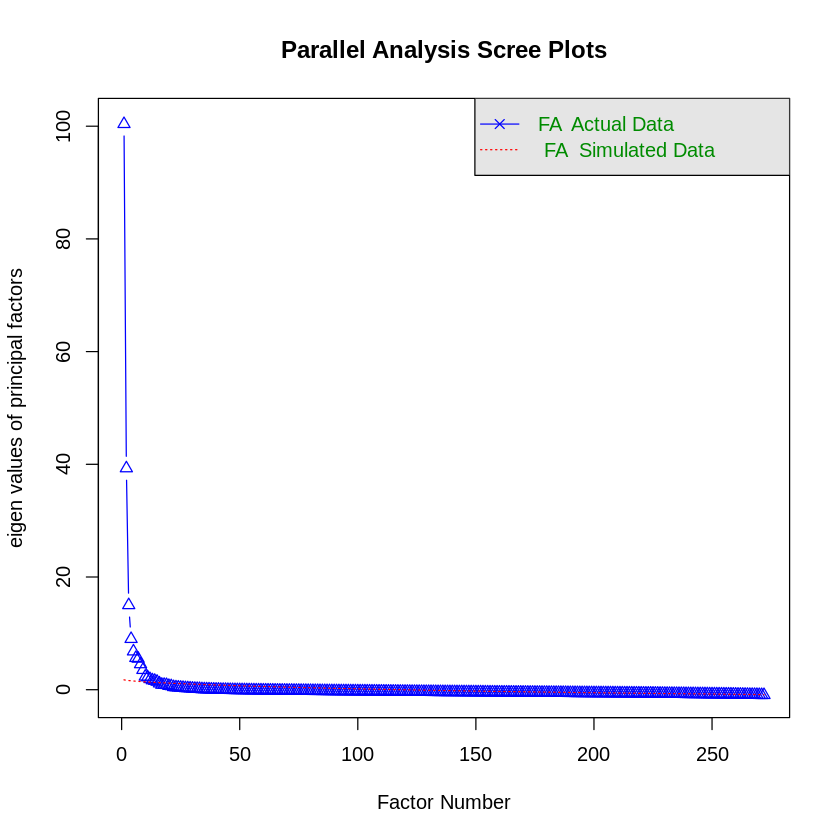

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2021 

PARALLEL ANALYSIS: 2021 
Variáveis finais: 271 


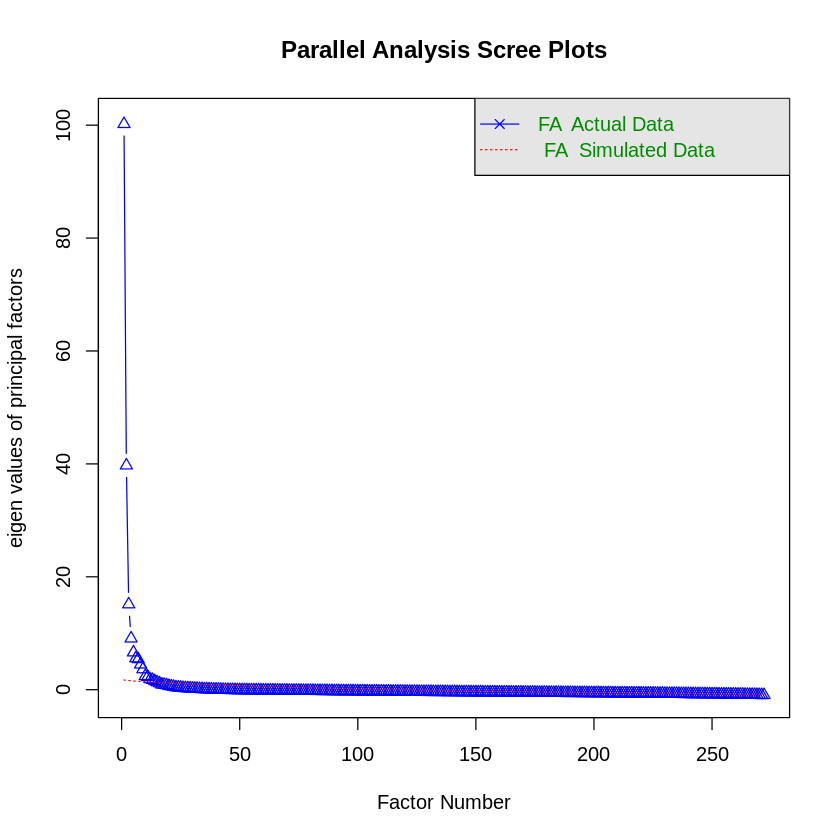

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2023 

PARALLEL ANALYSIS: 2023 
Variáveis finais: 271 


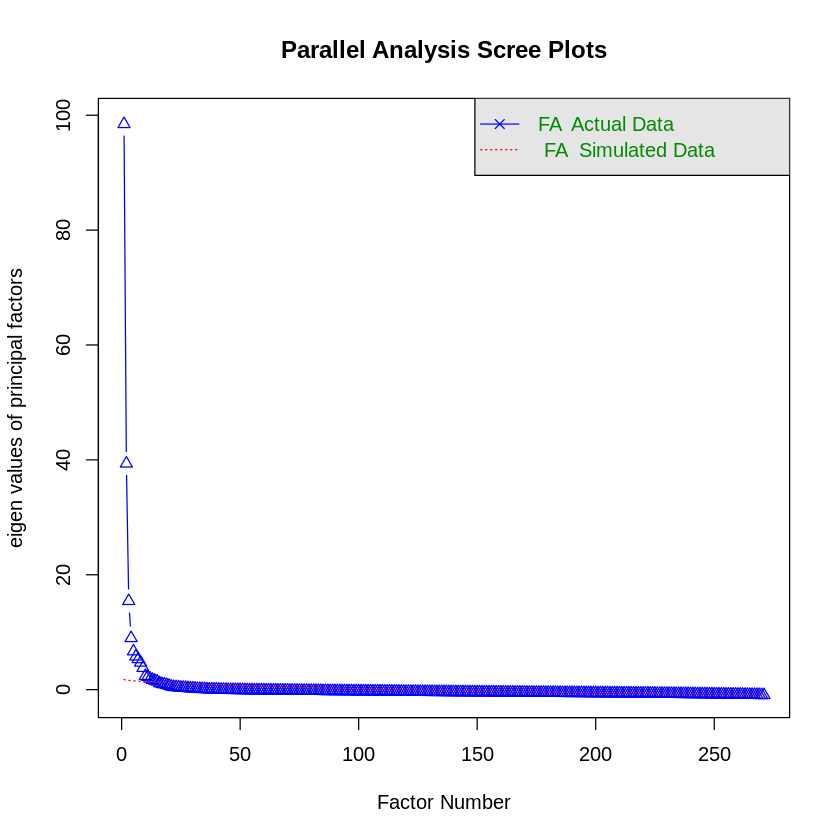

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 

ANO: 2025 

PARALLEL ANALYSIS: 2025 
Variáveis finais: 271 


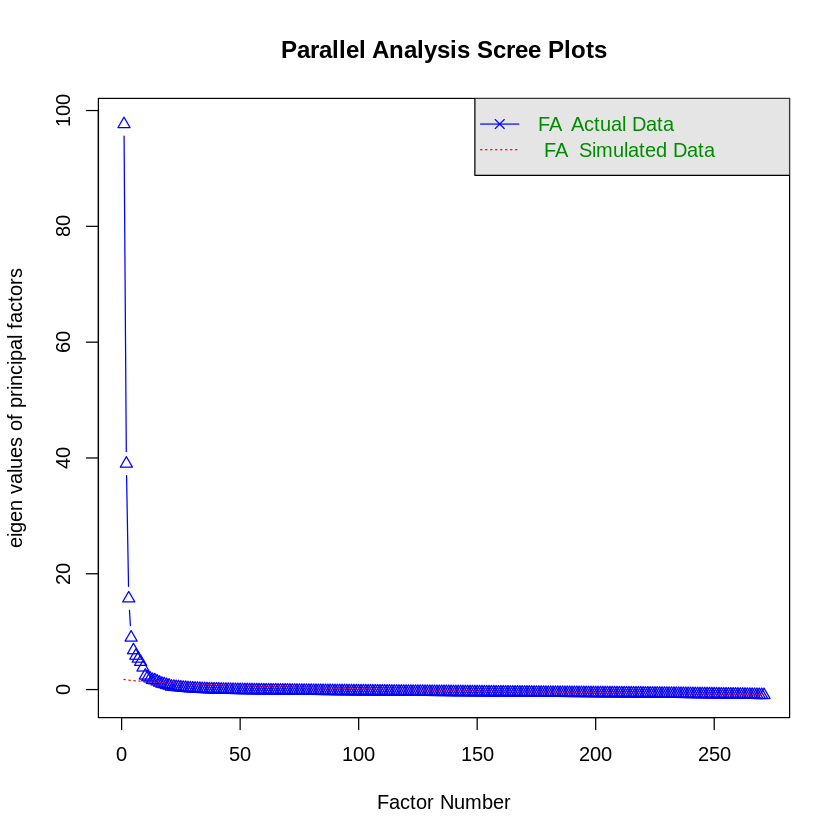

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


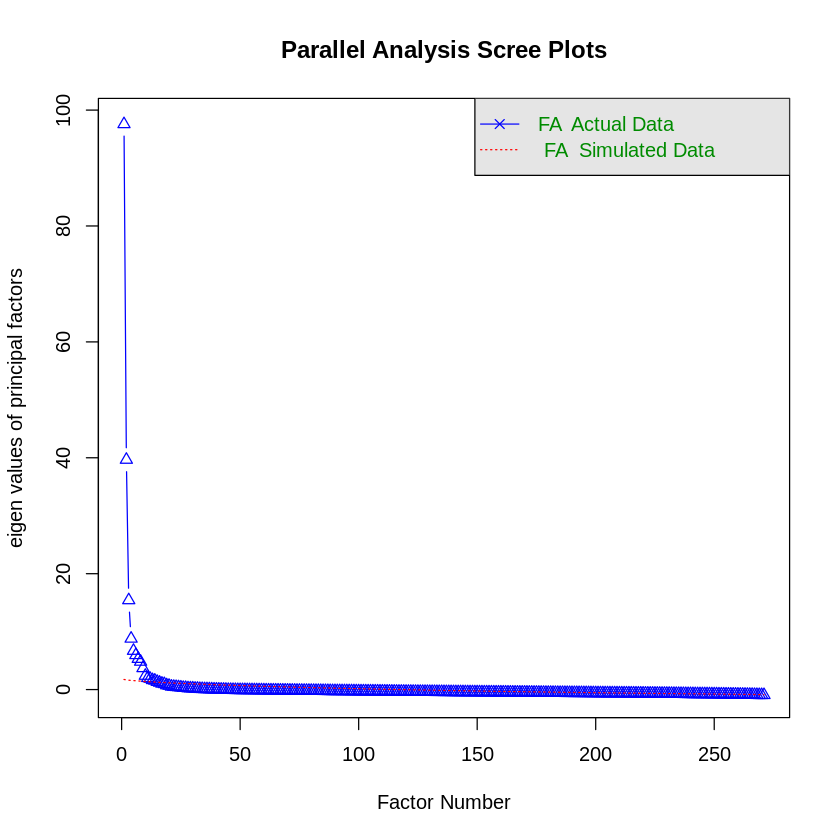

In [57]:
# =========================================================
# RODAR PARALLEL ANALYSIS POR ANO
# =========================================================

parallel_results <- list()

for(a in anos){

  cat("\nANO:", a, "\n")

  dados_ano <- efa_final[
    efa_final$Version_Year == a,
  ]

  dados_ano <- dados_ano %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  parallel_results[[as.character(a)]] <-
    run_parallel(dados_ano, a)
}

In [65]:
# =========================================================
# FUNÇÃO VSS
# =========================================================

run_vss <- function(data, ano){

  cat("\n====================================\n")
  cat("VSS:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # numeric
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # MATRIZ SPEARMAN
  # -------------------------------------------------------

  cor_mat <- cor(
    data,
    method = "spearman",
    use = "pairwise.complete.obs"
  )

  cor_mat[!is.finite(cor_mat)] <- 0
  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # VSS
  # -------------------------------------------------------

  res <- psych::VSS(
    cor_mat,
    n.obs = nrow(data),
    n = 5,
    rotate = "oblimin",
    fm = "minres",
    plot = TRUE
  )

  return(res)
}


ANO: 2017 

VSS: 2017 
Variáveis finais: 272 

ANO: 2019 

VSS: 2019 
Variáveis finais: 272 


Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPFoblq. 1000 iterations used.”


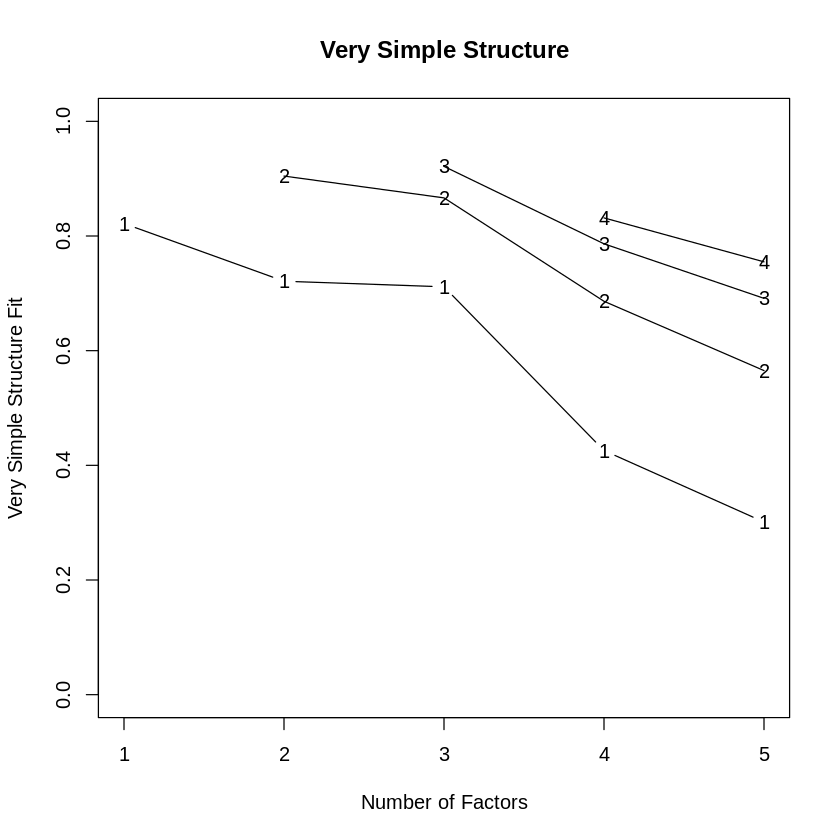


ANO: 2021 

VSS: 2021 
Variáveis finais: 271 


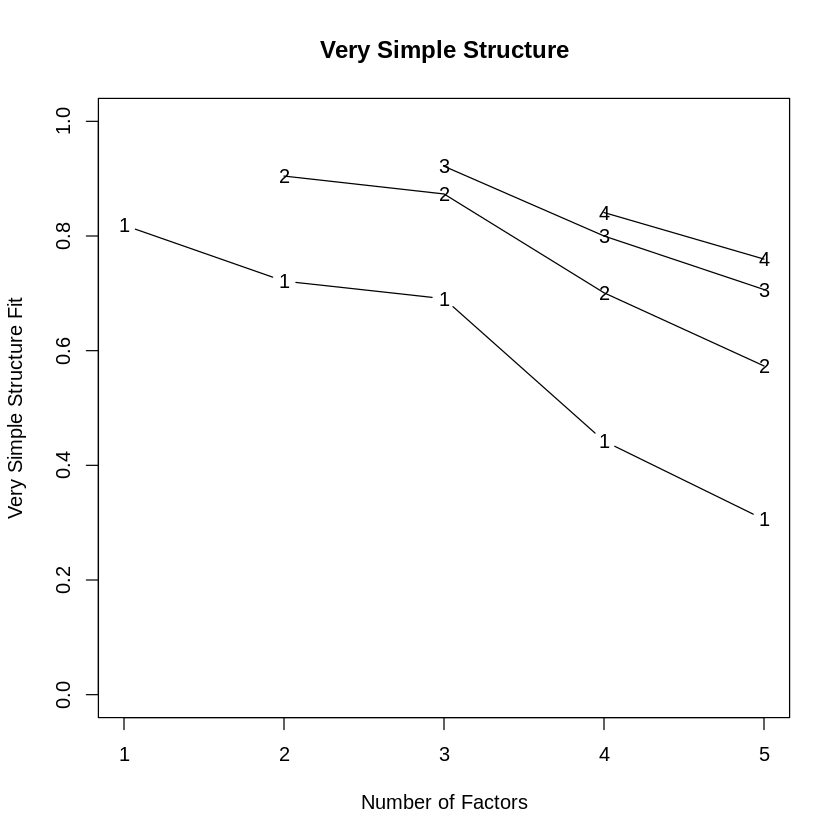


ANO: 2023 

VSS: 2023 
Variáveis finais: 271 


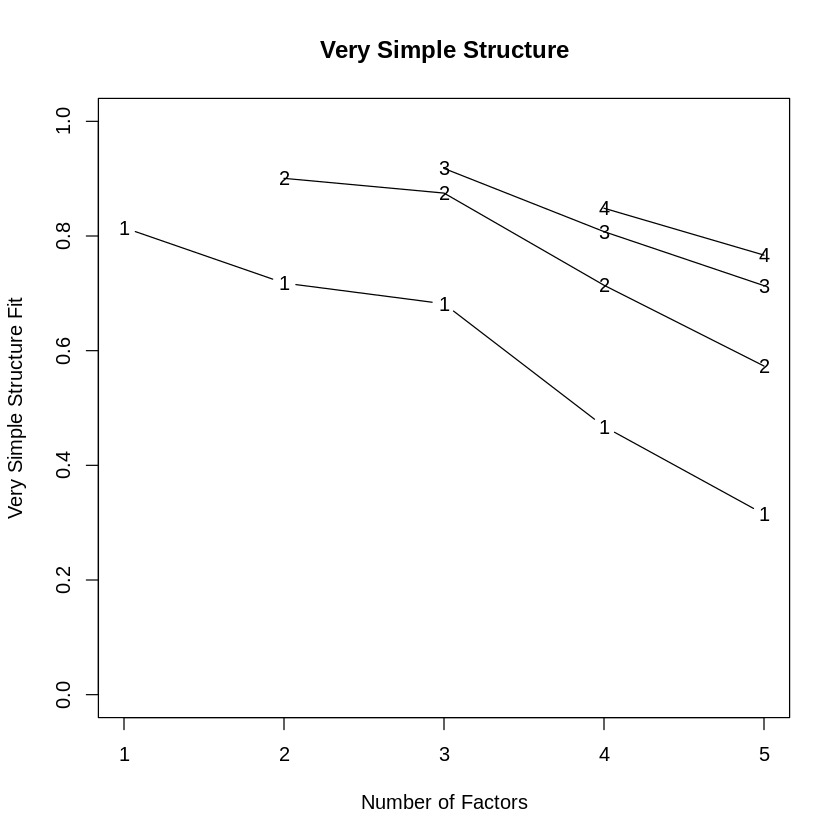


ANO: 2025 

VSS: 2025 
Variáveis finais: 271 


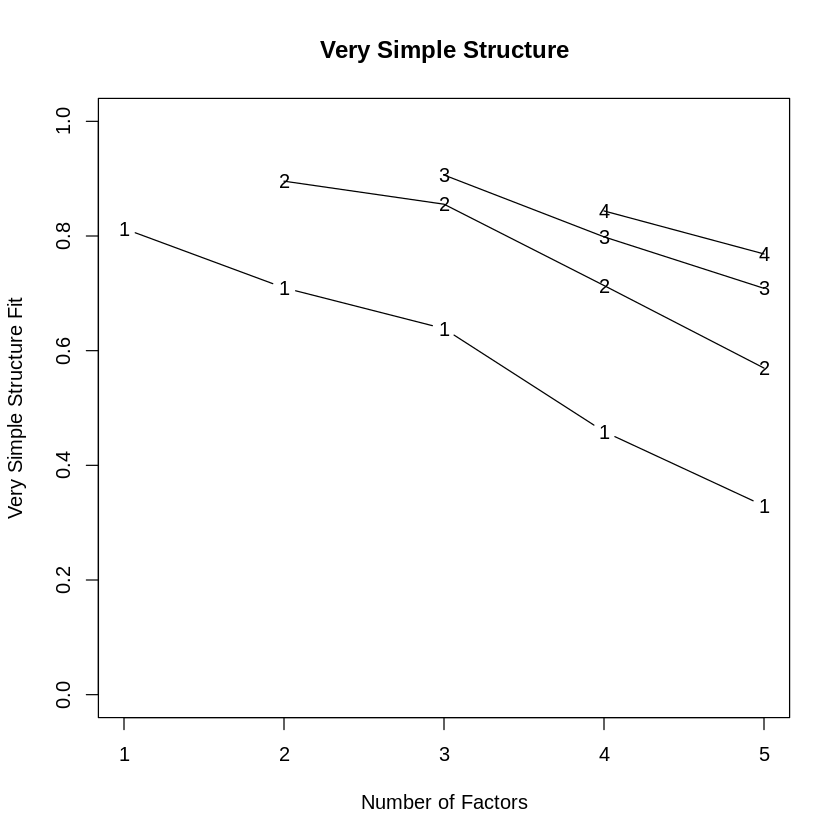

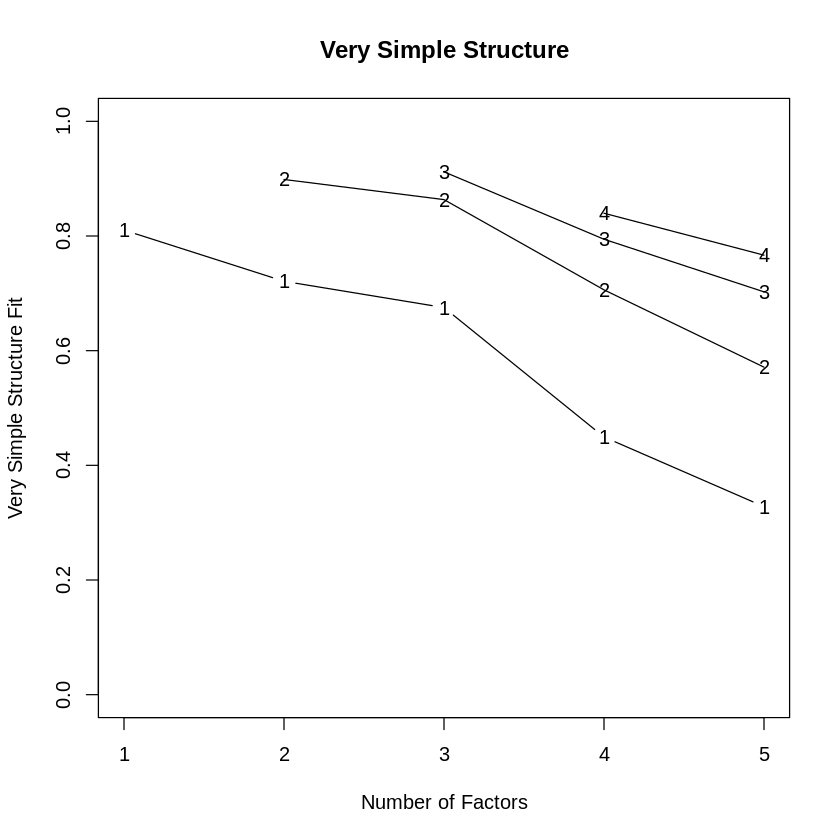

In [66]:
# =========================================================
# RODAR VSS POR ANO
# =========================================================

vss_results <- list()

for(a in anos){

  cat("\nANO:", a, "\n")

  dados_ano <- efa_final[
    efa_final$Version_Year == a,
  ]

  dados_ano <- dados_ano %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  vss_results[[as.character(a)]] <-
    run_vss(dados_ano, a)
}

In [67]:
vss_final_report <- map_dfr(
  names(vss_results),
  ~ {
    res <- vss_results[[.x]]
    tibble(
      Ano = as.numeric(.x),
      VSS1 = res$vss.stats[1, "fit"],
      VSS2 = res$vss.stats[2, "fit"],
      VSS3 = res$vss.stats[3, "fit"],
      VSS4 = res$vss.stats[4, "fit"],
      VSS5 = res$vss.stats[5, "fit"]
    )
  }
)

print(vss_final_report)

# A tibble: 5 × 6
    Ano  VSS1  VSS2  VSS3  VSS4  VSS5
  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1  2017 0.822 0.905 0.921 0.832 0.779
2  2019 0.819 0.905 0.922 0.841 0.784
3  2021 0.815 0.901 0.918 0.848 0.788
4  2023 0.813 0.896 0.906 0.844 0.789
5  2025 0.810 0.899 0.912 0.840 0.787


In [68]:
print(vss_results[['2017']]$vss.stats)

    dof    chisq prob   sqresid       fit      RMSEA       BIC    SABIC
1 36584 202968.4    0 2207.0175 0.8217312 0.08633112 -31661.58 84484.59
2 36313 165708.6    0 1182.0375 0.9045226 0.07641238 -67183.30 48102.51
3 36043 149590.7    0  973.5322 0.9213643 0.07184568 -81569.56 32859.05
4 35774 139733.3    0 2085.3149 0.8315616 0.06900178 -89701.76 23872.84
5 35506 131629.9    0 2741.0722 0.7785937 0.06659908 -96086.35 16637.41
   complex    eChisq       SRMR      eCRMS       eBIC       eRMS    cfit.1
1 1.000000 635362.29 0.11887122 0.11931230  400732.31 0.11887122 0.8217312
2 1.295661 160630.94 0.05976963 0.06021485  -72260.99 0.05976963 0.7211282
3 1.534247  90271.50 0.04480653 0.04530905 -140888.80 0.04480653 0.7113650
4 1.865137  64139.58 0.03776844 0.03833535 -165295.50 0.03776844 0.4257808
5 2.181155  48963.08 0.03299897 0.03362045 -178753.19 0.03299897 0.3010892
     cfit.2    cfit.3    cfit.4    cfit.5 cresidual.1 cresidual.2 cresidual.3
1 0.0000000 0.0000000 0.0000000 0.000000

In [64]:
# =========================================================
# FUNÇÃO VSS E MAP 5 promax
# =========================================================

run_factor_selection <- function(data, ano){

  cat("\n====================================\n")
  cat("Análise:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # Limpeza de dados (NA, Variância Zero, Imputação e Tipo)
  # -------------------------------------------------------
  data <- data %>%
    select(where(~ !all(is.na(.)))) %>%
    select(where(~ {
      s <- sd(., na.rm = TRUE)
      !is.na(s) && s > 0
    })) %>%
    mutate(across(everything(), ~ ifelse(is.na(.), median(., na.rm = TRUE), .))) %>%
    mutate(across(everything(), as.numeric))

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # MATRIZ SPEARMAN
  # -------------------------------------------------------
  cor_mat <- cor(
    data,
    method = "spearman",
    use = "pairwise.complete.obs"
  )

  cor_mat[!is.finite(cor_mat)] <- 0
  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # EXECUTAR VSS (Aumentado n para 15 devido à Análise Paralela)
  # -------------------------------------------------------
  # Aumentamos 'n' para que o VSS avalie até 15 fatores se necessário
  vss_res <- psych::VSS(
    cor_mat,
    n.obs = nrow(data),
    n = 5,
    rotate = "promax",
    fm = "minres",
    plot = FALSE
  )

  # -------------------------------------------------------
  # EXECUTAR MAP DE VELICER
  # -------------------------------------------------------
  # A função vss() executa o MAP internamente e salva em $map
  # O número ideal de fatores pelo MAP é onde o valor é MINIMIZADO (índice do menor valor)
  map_values <- vss_res$map
  map_sugerido <- which.min(map_values)

  # Retorna tanto os resultados do VSS quanto o MAP sugerido
  return(list(vss = vss_res, map_factors = map_sugerido))
}

# =========================================================
# RODAR POR ANO E GERAR RELATÓRIO
# =========================================================

analise_results <- list()

for(a in anos){

  cat("\nANO:", a, "\n")

  dados_ano <- efa_final[efa_final$Version_Year == a, ]

  dados_ano <- dados_ano %>%
    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  analise_results[[as.character(a)]] <- run_factor_selection(dados_ano, a)
}

# Criar relatório consolidado
final_report <- map_dfr(
  names(analise_results),
  ~ {
    res_vss <- analise_results[[.x]]$vss
    map_sug  <- analise_results[[.x]]$map_factors

    tibble(
      Ano = as.numeric(.x),
      VSS1_Fit = res_vss$vss.stats[1, "fit"],
      VSS2_Fit = res_vss$vss.stats[2, "fit"],
      VSS3_Fit = res_vss$vss.stats[3, "fit"],
      VSS4_Fit = res_vss$vss.stats[4, "fit"],
      VSS5_Fit = res_vss$vss.stats[5, "fit"],
      MAP_Sugerido = map_sug
    )
  }
)

print(final_report)


ANO: 2017 

Análise: 2017 
Variáveis finais: 272 

ANO: 2019 

Análise: 2019 
Variáveis finais: 272 

ANO: 2021 

Análise: 2021 
Variáveis finais: 271 


Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPForth. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPF

In [49]:
# =========================================================
# FUNÇÃO VSS + MAP 5 promax
# =========================================================

run_vss_map <- function(data, ano, max_factors = 20){

  cat("\n====================================\n")
  cat("VSS + MAP:", ano, "\n")
  cat("====================================\n")

  # -------------------------------------------------------
  # remover colunas totalmente NA
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ !all(is.na(.)))
    )

  # -------------------------------------------------------
  # remover variância zero
  # -------------------------------------------------------

  data <- data %>%
    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    )

  # -------------------------------------------------------
  # imputação simples
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  # -------------------------------------------------------
  # converter para numérico
  # -------------------------------------------------------

  data <- data %>%
    mutate(
      across(
        everything(),
        as.numeric
      )
    )

  cat("Variáveis finais:", ncol(data), "\n")

  # -------------------------------------------------------
  # matriz de correlação Spearman
  # -------------------------------------------------------

  cor_mat <- cor(
    data,
    method = "spearman",
    use = "pairwise.complete.obs"
  )

  cor_mat[!is.finite(cor_mat)] <- 0

  diag(cor_mat) <- 1

  # -------------------------------------------------------
  # VSS
  # -------------------------------------------------------

  res <- psych::VSS(
    cor_mat,
    n = 5,
    n.obs = nrow(data),
    rotate = "promax",
    fm = "minres",
    plot = FALSE
  )

  # -------------------------------------------------------
  # MAP
  # -------------------------------------------------------

  map_factors <- which.min(res$map)

  # -------------------------------------------------------
  # VSS
  # -------------------------------------------------------

  vss1_factors <- which.max(res$cfit.1)

  vss2_factors <- which.max(res$cfit.2)

  cat("MAP sugere:", map_factors, "fatores\n")
  cat("VSS1 sugere:", vss1_factors, "fatores\n")
  cat("VSS2 sugere:", vss2_factors, "fatores\n")

  return(res)

}

# =========================================================
# EXECUTAR PARA TODOS OS ANOS
# =========================================================

vss_results <- list()

for(a in anos){

  dados_ano <- efa_final %>%

    filter(
      Version_Year == a
    ) %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    )

  vss_results[[as.character(a)]] <-
    run_vss_map(
      dados_ano,
      a,
      max_factors = 20
    )

}

# =========================================================
# TABELA RESUMO
# =========================================================

tabela_diagnostico <- data.frame()

for(a in names(vss_results)){

  res <- vss_results[[a]]

  tabela_diagnostico <-

    rbind(

      tabela_diagnostico,

      data.frame(

        Ano = a,

        MAP_Fatores =
          which.min(res$map),

        MAP_Min =
          round(min(res$map), 4),

        VSS1_Fatores =
          which.max(res$cfit.1),

        VSS1_Max =
          round(max(res$cfit.1), 4),

        VSS2_Fatores =
          which.max(res$cfit.2),

        VSS2_Max =
          round(max(res$cfit.2), 4)

      )

    )

}


VSS + MAP: 2017 
Variáveis finais: 320 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2019 
Variáveis finais: 320 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2021 
Variáveis finais: 320 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2023 
Variáveis finais: 320 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores

VSS + MAP: 2025 
Variáveis finais: 320 
MAP sugere: 5 fatores
VSS1 sugere: 1 fatores
VSS2 sugere: 2 fatores


   Ano MAP_Fatores MAP_Min VSS1_Fatores VSS1_Max VSS2_Fatores VSS2_Max
1 2017           5  0.0176            1   0.8358            2   0.8755
2 2019           5  0.0178            1   0.8332            2   0.8766
3 2021           5  0.0183            1   0.8291            2   0.8779
4 2023           5  0.0183            1   0.8298            2   0.8764
5 2025           5  0.0171            1   0.8258            2   0.8806


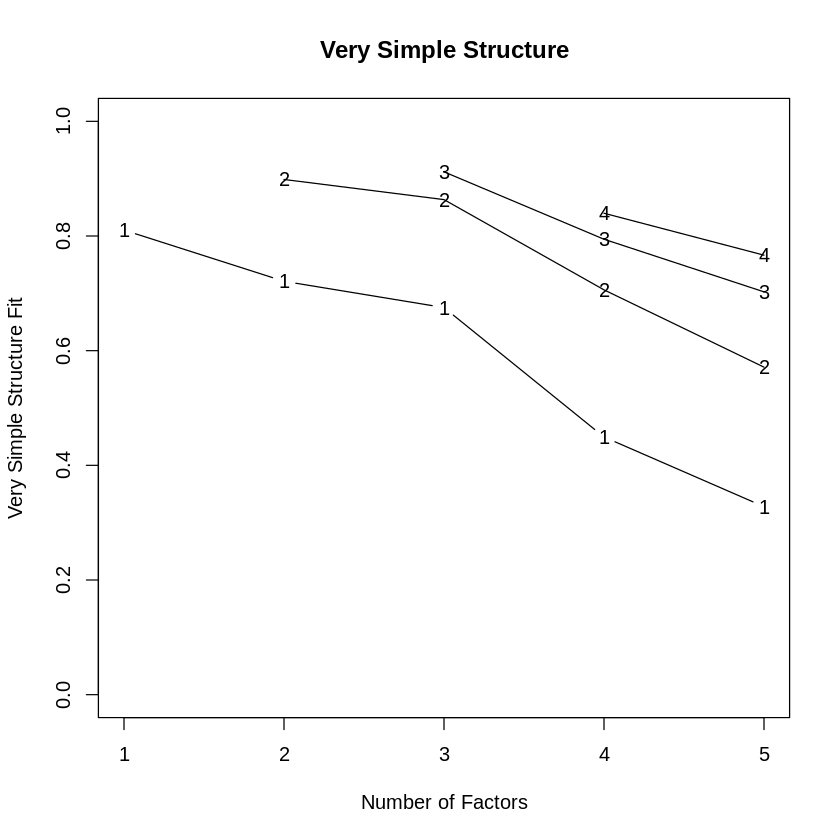

In [69]:
# =========================================================
# RESULTADO FINAL
# =========================================================

print(tabela_diagnostico)

# =========================================================
# GRÁFICO DO ÚLTIMO ANO
# =========================================================

ultimo_ano <- tail(names(vss_results), 1)

plot(
  vss_results[[ultimo_ano]],
  main = paste(
    "VSS -",
    ultimo_ano
  )
)

### Análise Fatorial Exploratória

In [70]:
rename_onet <- c(

  "Administrative - Level" =
    "Clerical - Level",

  "Administrative - Importance" =
    "Clerical - Importance",

  "Working with Computers - Level" =
    "Interacting With Computers - Level",

  "Working with Computers - Importance" =
    "Interacting With Computers - Importance",

  "Communicating with People Outside the Organization - Level" =
    "Communicating with Persons Outside Organization - Level",

  "Communicating with People Outside the Organization - Importance" =
    "Communicating with Persons Outside Organization - Importance",

  "Inspecting Equipment, Structures, or Materials - Level" =
    "Inspecting Equipment, Structures, or Material - Level",

  "Inspecting Equipment, Structures, or Materials - Importance" =
    "Inspecting Equipment, Structures, or Material - Importance",

  "Providing Consultation and Advice to Others - Level" =
    "Provide Consultation and Advice to Others - Level",

  "Providing Consultation and Advice to Others - Importance" =
    "Provide Consultation and Advice to Others - Importance",

  "Operations Monitoring - Level" =
    "Operation Monitoring - Level",

  "Operations Monitoring - Importance" =
    "Operation Monitoring - Importance",

  "Judging the Qualities of Objects, Services, or People - Level" =
    "Judging the Qualities of Things, Services, or People - Level",

  "Judging the Qualities of Objects, Services, or People - Importance" =
    "Judging the Qualities of Things, Services, or People - Importance"
)

names(efa_final) <- recode(
  names(efa_final),
  !!!rename_onet
)

In [72]:
anos <- sort(unique(efa_final$Version_Year))

# Garante que os nomes das colunas são únicos antes de qualquer operação dplyr
names(efa_final) <- make.unique(names(efa_final))

vars_por_ano <- list()

for(a in anos){

  vars_por_ano[[as.character(a)]] <-

    efa_final %>%

    filter(Version_Year == a) %>%

    select(
      -`O*NET-SOC Code`,
      -Title,
      -Version_Year
    ) %>%

    select(
      where(~ {
        s <- sd(., na.rm = TRUE)
        !is.na(s) && s > 0
      })
    ) %>%

    names()
}

vars_comuns <- Reduce(
  intersect,
  vars_por_ano
)

length(vars_comuns)

[1] 256

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


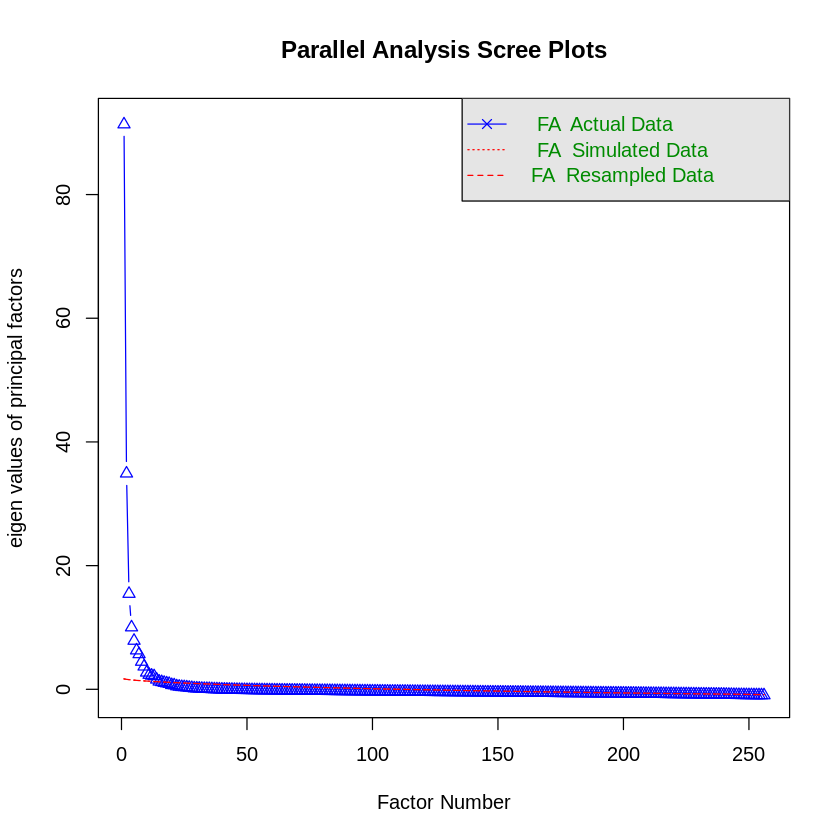

Parallel analysis suggests that the number of factors =  14  and the number of components =  NA 


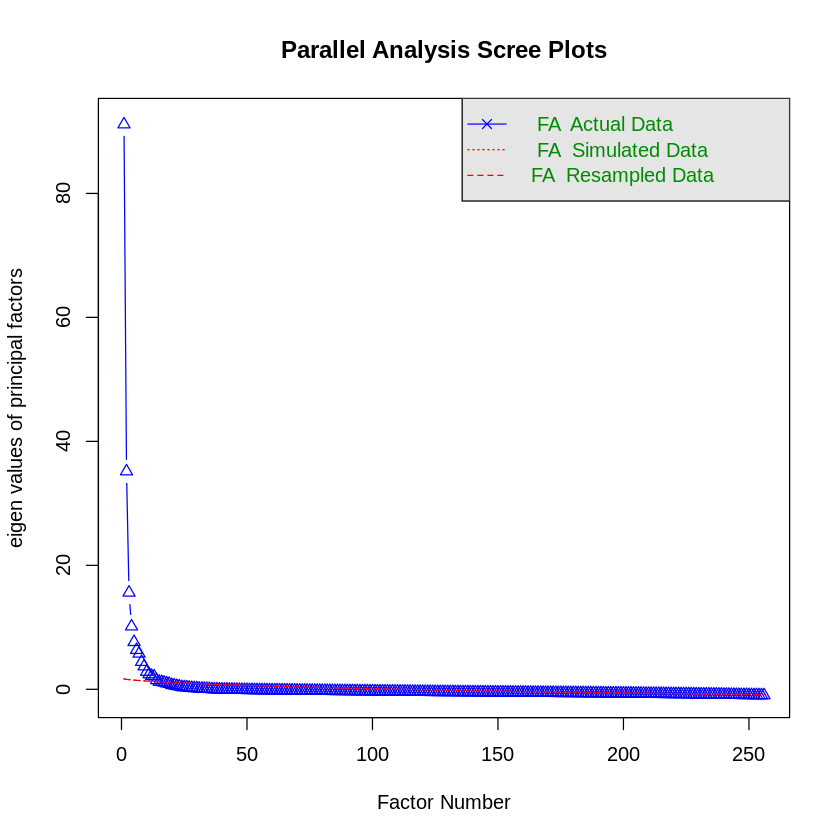

Parallel analysis suggests that the number of factors =  14  and the number of components =  NA 


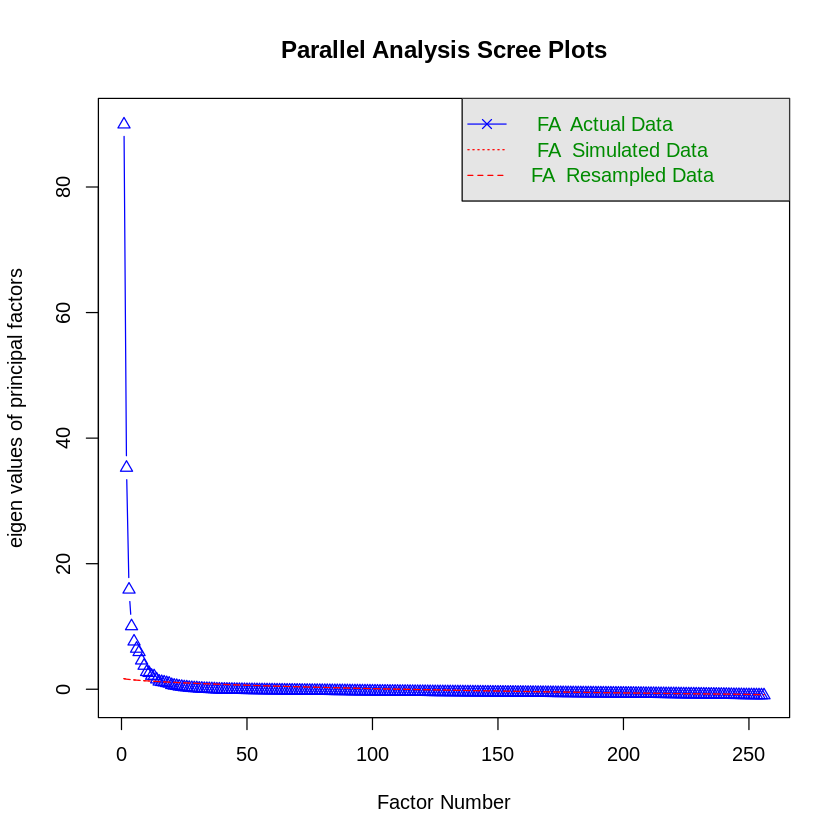

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


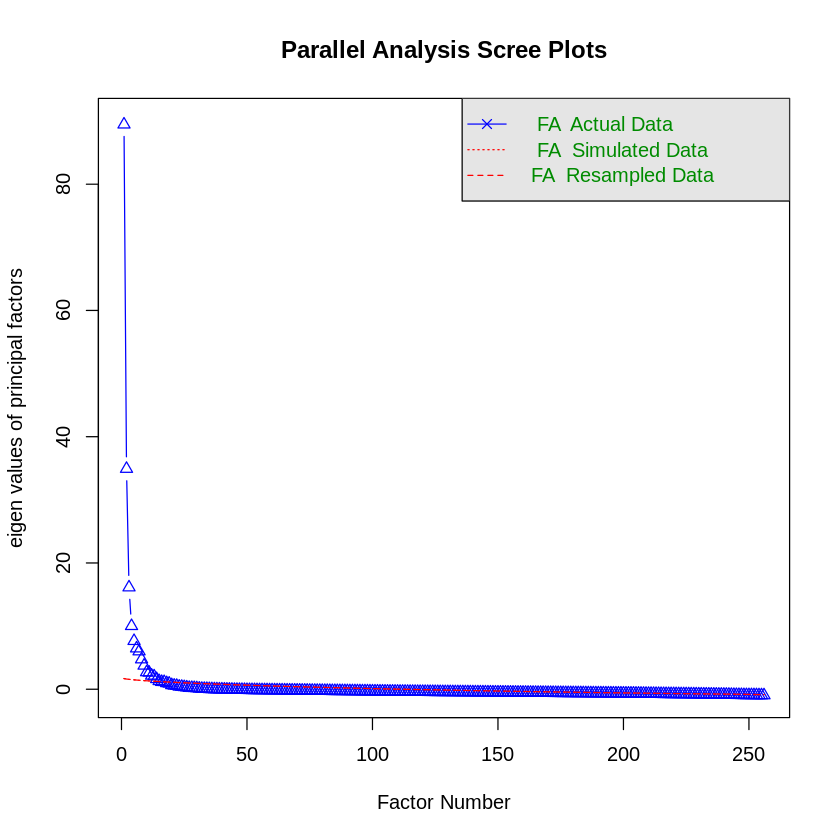

Parallel analysis suggests that the number of factors =  15  and the number of components =  NA 


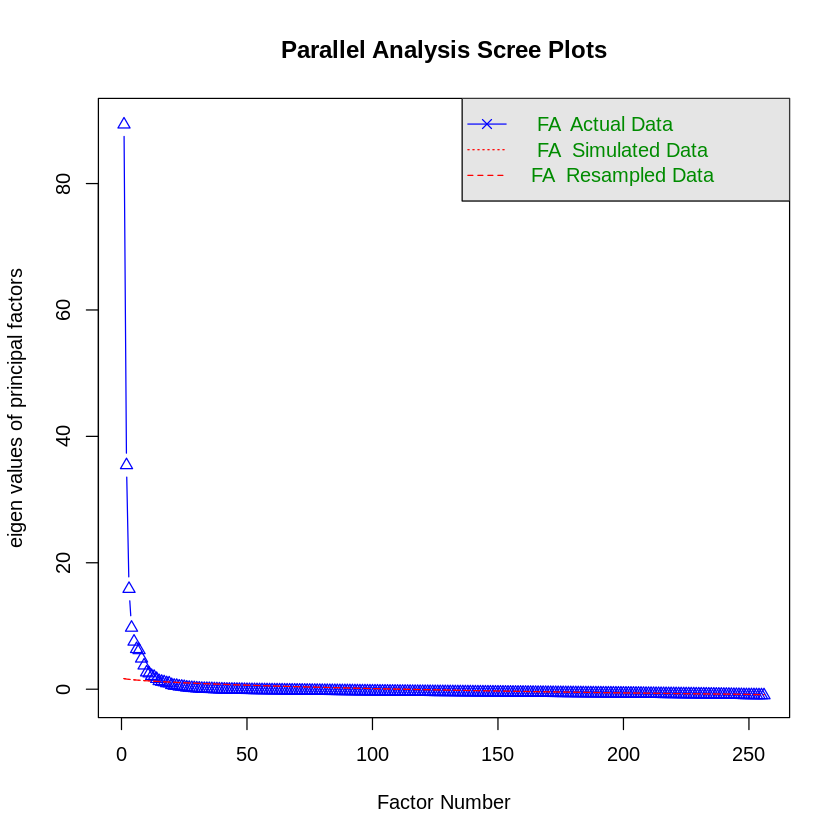

In [73]:
parallel_results <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(Version_Year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  parallel_results[[as.character(a)]] <-

    fa.parallel(

      dados,

      fa = "fa",

      fm = "minres",

      cor = "cor",

      n.iter = 100

    )

}

In [74]:
vss_results1 <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(Version_Year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  cor_mat <- cor(
    dados,
    method = "spearman"
  )

  vss_results1[[as.character(a)]] <-

    VSS(
      cor_mat,
      n = 5,
      fm = "minres",
      rotate = "oblimin",
      n.obs = nrow(dados),
      plot = FALSE
    )

}

In [75]:
vss_report <- map_dfr(

  names(vss_results1),

  function(a){

    res <- vss_results1[[a]]

    tibble(

      Ano = as.numeric(a),

      VSS1_Fit = res$vss.stats[1,"fit"],
      VSS2_Fit = res$vss.stats[2,"fit"],
      VSS3_Fit = res$vss.stats[3,"fit"],
      VSS4_Fit = res$vss.stats[4,"fit"],
      VSS5_Fit = res$vss.stats[5,"fit"],

      MAP_Sugerido = which.min(res$map),
      MAP_Min = min(res$map)

    )

  }

)

print(vss_report)

# A tibble: 5 × 8
    Ano VSS1_Fit VSS2_Fit VSS3_Fit VSS4_Fit VSS5_Fit MAP_Sugerido MAP_Min
  <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>        <int>   <dbl>
1  2017    0.826    0.901    0.916    0.828    0.770            5  0.0164
2  2019    0.823    0.901    0.916    0.837    0.774            5  0.0164
3  2021    0.818    0.895    0.911    0.847    0.782            5  0.0165
4  2023    0.817    0.890    0.900    0.844    0.784            5  0.0164
5  2025    0.814    0.893    0.905    0.841    0.784            5  0.0163


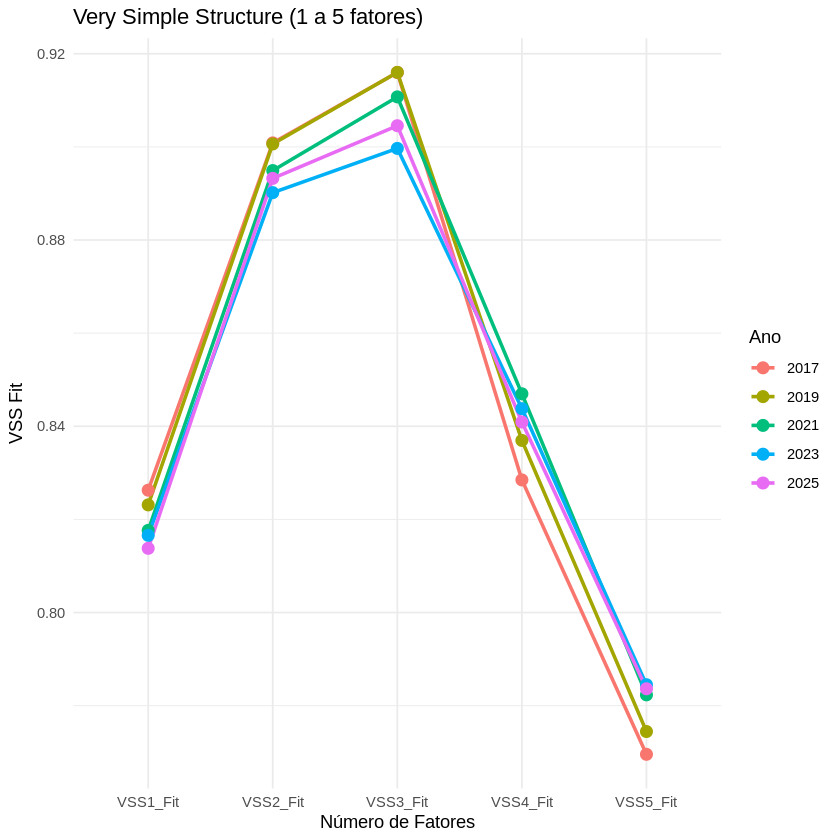

In [76]:
vss_long <- vss_report %>%

  pivot_longer(

    cols = starts_with("VSS"),

    names_to = "Modelo",

    values_to = "Fit"

  )

ggplot(

  vss_long,

  aes(
    x = Modelo,
    y = Fit,
    group = Ano,
    color = factor(Ano)
  )

) +

  geom_line(linewidth = 1) +

  geom_point(size = 3) +

  labs(

    title = "Very Simple Structure (1 a 5 fatores)",

    x = "Número de Fatores",

    y = "VSS Fit",

    color = "Ano"

  ) +

  theme_minimal()

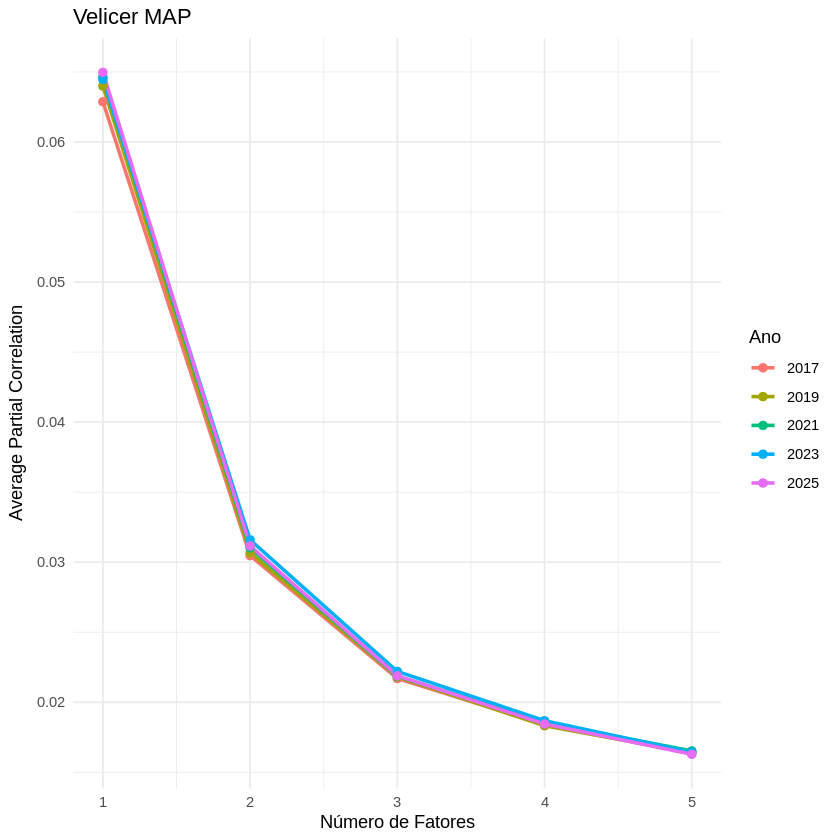

In [77]:
map_report <- map_dfr(

  names(vss_results1),

  function(a){

    tibble(

      Ano = as.numeric(a),

      Fatores = 1:length(vss_results1[[a]]$map),

      MAP = vss_results1[[a]]$map

    )

  }

)

ggplot(

  map_report,

  aes(

    x = Fatores,

    y = MAP,

    color = factor(Ano)

  )

) +

  geom_line(linewidth = 1) +

  geom_point(size = 2) +

  labs(

    title = "Velicer MAP",

    x = "Número de Fatores",

    y = "Average Partial Correlation",

    color = "Ano"

  ) +

  theme_minimal()


Ano: 2017 

Ano: 2019 


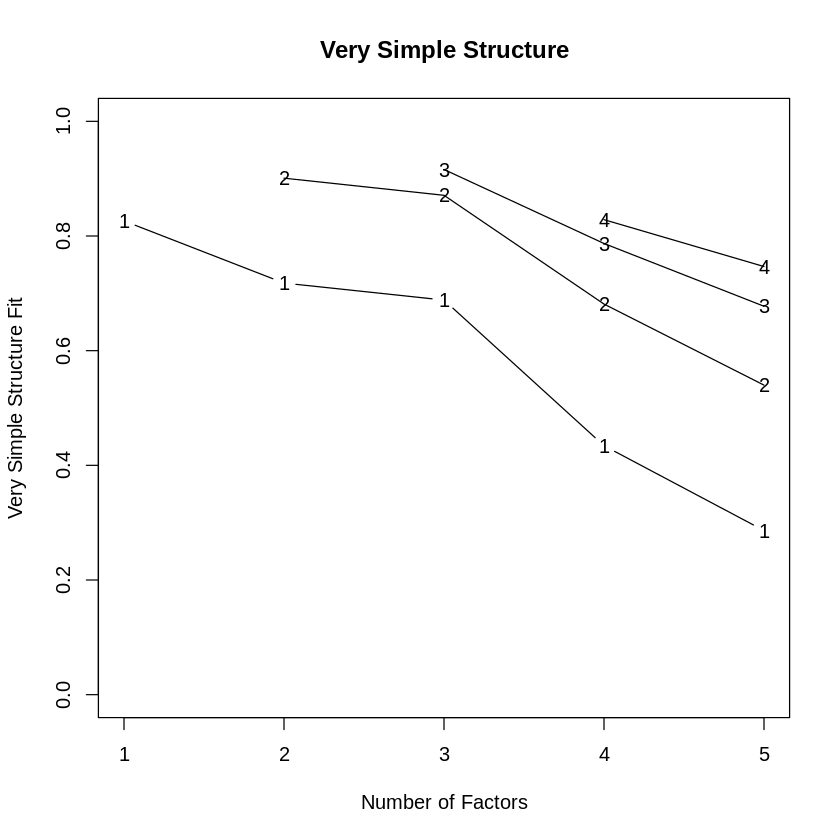


Ano: 2021 


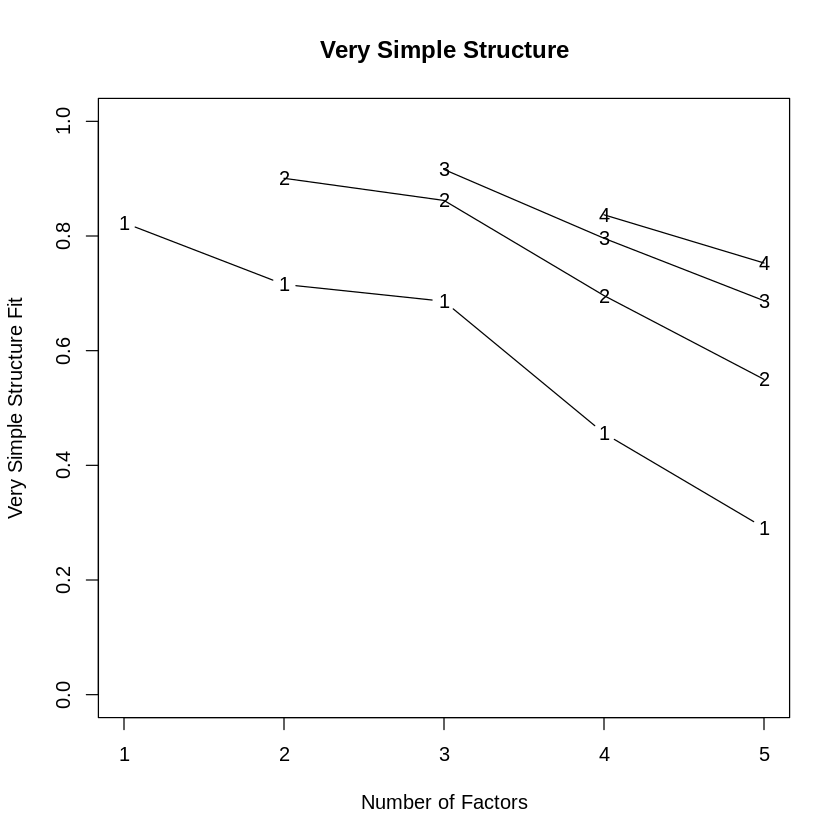


Ano: 2023 


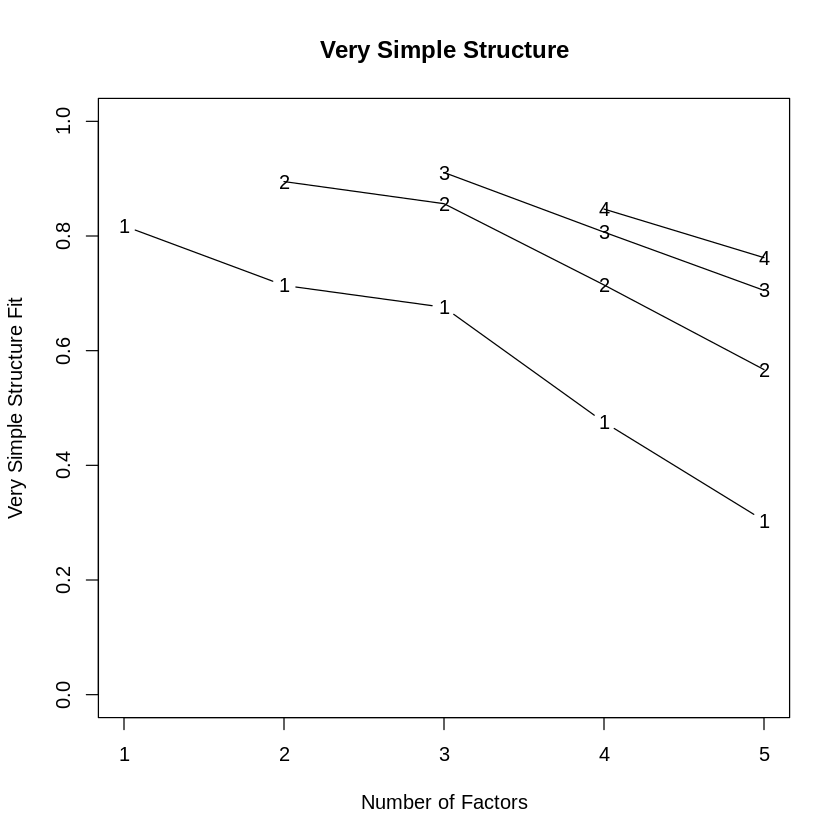


Ano: 2025 


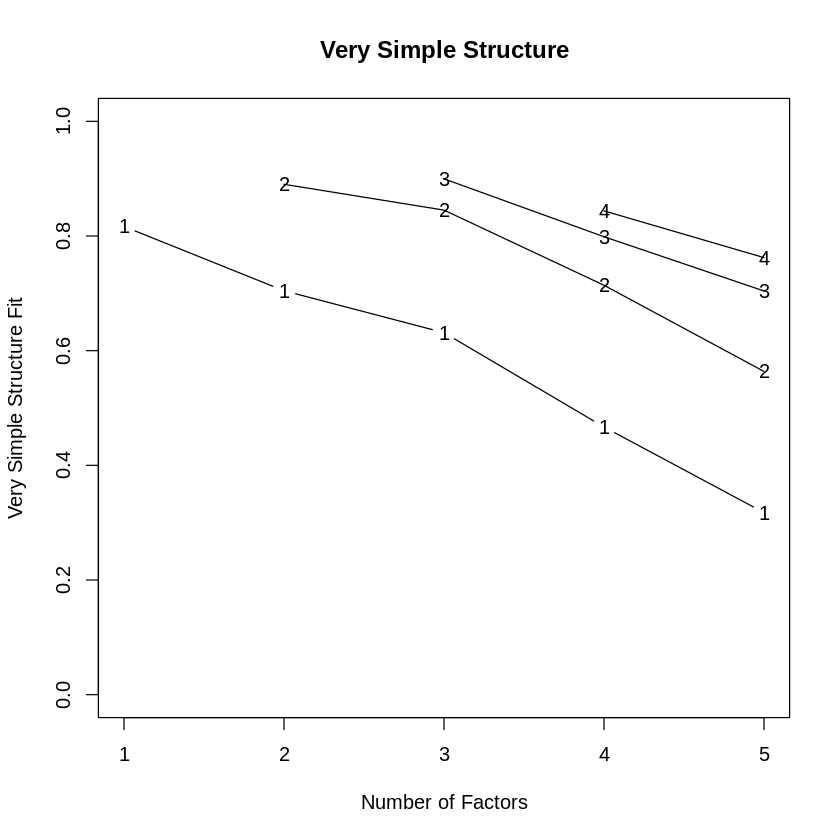

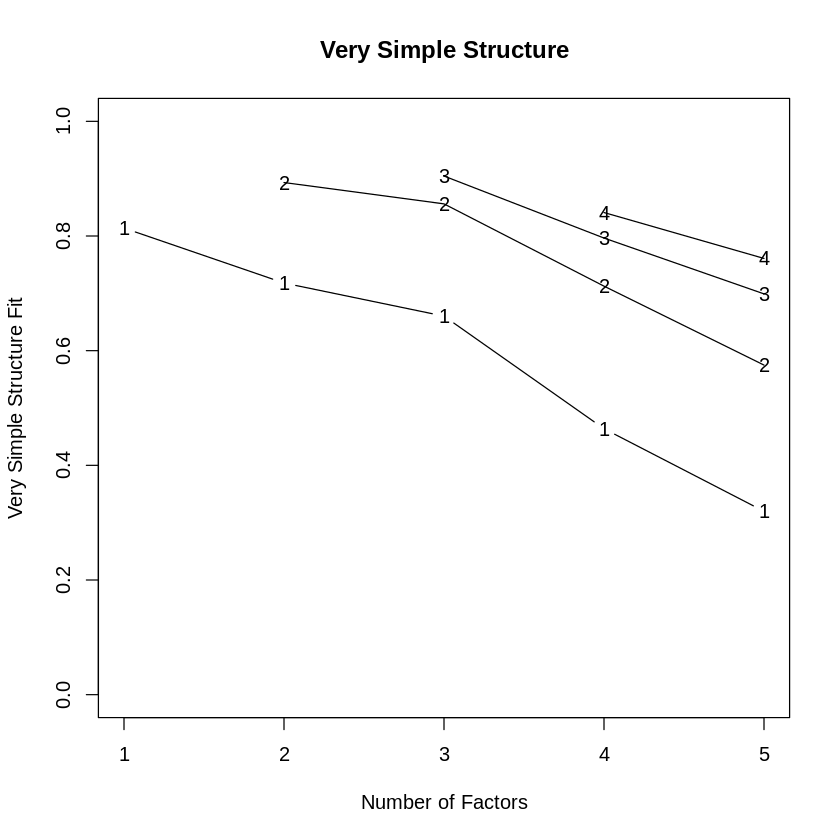

In [78]:
for(a in names(vss_results1)){

  cat("\nAno:", a, "\n")

  plot(

    vss_results1[[a]],

    main = paste(
      "VSS -",
      a
    )

  )

}

In [79]:
efa_5fatores <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(Version_Year == a) %>%

    select(
      all_of(vars_comuns)
    )

  dados <- dados %>%

    mutate(
      across(
        everything(),
        ~ ifelse(
          is.na(.),
          median(., na.rm = TRUE),
          .
        )
      )
    )

  cor_mat <- cor(
    dados,
    method = "spearman"
  )

  efa_5fatores[[as.character(a)]] <-

    fa(

      cor_mat,

      nfactors = 5,

      rotate = "oblimin",

      fm = "minres",

      n.obs = nrow(dados)

    )
}

Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPFoblq. 1000 iterations used.”
Warning message in engine(A, Tmat = current_Tmat, normalize = normalize, eps = eps, :
“Convergence not obtained in GPFoblq. 1000 iterations used.”


In [80]:
comparacoes <- data.frame()

for(i in 1:(length(anos)-1)){

  a1 <- as.character(anos[i])
  a2 <- as.character(anos[i+1])

  cong <- factor.congruence(
    efa_5fatores[[a1]],
    efa_5fatores[[a2]]
  )

  comparacoes <- rbind(

    comparacoes,

    data.frame(

      Ano1 = a1,

      Ano2 = a2,

      Congruencia_Media =
        mean(
          apply(abs(cong),1,max)
        )

    )
  )
}

comparacoes

Ano1,Ano2,Congruencia_Media
<chr>,<chr>,<dbl>
2017,2019,0.994
2019,2021,0.994
2021,2023,0.992
2023,2025,1.000


In [81]:
loadings_2017 <- as.data.frame(
  unclass(efa_5fatores[["2017"]]$loadings)
)

loadings_2025 <- as.data.frame(
  unclass(efa_5fatores[["2025"]]$loadings)
)

In [82]:
factor.congruence(
  efa_5fatores[["2017"]],
  efa_5fatores[["2019"]]
)

factor.congruence(
  efa_5fatores[["2019"]],
  efa_5fatores[["2021"]]
)

factor.congruence(
  efa_5fatores[["2021"]],
  efa_5fatores[["2023"]]
)

factor.congruence(
  efa_5fatores[["2023"]],
  efa_5fatores[["2025"]]
)

,MR5,MR3,MR4,MR2,MR1
MR4,1.00,-0.18,-0.14,-0.17,0.17
MR3,-0.18,0.99,0.38,0.35,-0.16
MR2,-0.09,0.38,1.00,0.26,0.12
MR1,-0.15,0.43,0.27,0.99,-0.02
MR5,0.24,0.00,0.08,-0.10,0.99


,MR4,MR5,MR2,MR1,MR3
MR5,1.00,-0.15,-0.14,-0.17,0.16
MR3,-0.17,0.99,0.39,0.32,-0.10
MR4,-0.10,0.41,1.00,0.23,0.12
MR2,-0.15,0.43,0.26,0.99,-0.01
MR1,0.23,-0.02,0.08,-0.13,0.99


,MR1,MR3,MR5,MR2,MR4
MR4,1.00,-0.15,-0.14,-0.14,-0.14
MR5,-0.14,0.99,0.39,0.40,0.18
MR2,-0.10,0.44,0.99,0.19,-0.08
MR1,-0.18,0.31,0.28,0.99,0.16
MR3,0.23,0.04,0.07,-0.02,-0.99


,MR1,MR4,MR5,MR2,MR3
MR1,1.00,-0.13,-0.13,-0.14,-0.18
MR3,-0.13,1.00,0.42,0.36,0.12
MR5,-0.12,0.41,1.00,0.26,0.00
MR2,-0.14,0.35,0.24,1.00,0.18
MR4,-0.19,0.08,-0.06,0.07,1.00


In [83]:
segunda_ordem <- list()

for(a in anos){

  segunda_ordem[[as.character(a)]] <-

    fa(

      efa_5fatores[[as.character(a)]]$Phi,

      nfactors = 2,

      rotate = "oblimin",

      fm = "minres"

    )

}

In [84]:
scores_longitudinais <- list()

for(a in anos){

  dados <- efa_final %>%

    filter(Version_Year == a)

  vars <- vars_comuns

  scores <- factor.scores(

    dados[, vars],

    efa_5fatores[[as.character(a)]],

    method = "tenBerge"

  )

  scores_longitudinais[[as.character(a)]] <-

    bind_cols(

      dados,

      as.data.frame(scores$scores)

    )
}

In [85]:
for(a in names(segunda_ordem)){

  cat("\n========================\n")
  cat("ANO:", a, "\n")
  cat("========================\n")

  print(
    segunda_ordem[[a]]$loadings,
    cutoff = 0.30
  )

}


ANO: 2017 

Loadings:
    MR1    MR2   
MR4 -0.354       
MR3  0.725       
MR2  0.585       
MR1  0.637       
MR5         0.741

                 MR1   MR2
SS loadings    1.399 0.702
Proportion Var 0.280 0.140
Cumulative Var 0.280 0.420

ANO: 2019 

Loadings:
    MR1    MR2   
MR5 -0.336       
MR3  0.753       
MR4  0.587       
MR2  0.607       
MR1         0.719

                 MR1   MR2
SS loadings    1.393 0.657
Proportion Var 0.279 0.131
Cumulative Var 0.279 0.410

ANO: 2021 

Loadings:
    MR1    MR2   
MR4 -0.326  0.301
MR5  0.778       
MR2  0.592       
MR1  0.560       
MR3         0.651

                 MR1   MR2
SS loadings    1.377 0.573
Proportion Var 0.275 0.115
Cumulative Var 0.275 0.390

ANO: 2023 

Loadings:
    MR1    MR2   
MR1              
MR3  0.793       
MR5  0.610       
MR2  0.512       
MR4         0.684

                 MR1   MR2
SS loadings    1.345 0.598
Proportion Var 0.269 0.120
Cumulative Var 0.269 0.388

ANO: 2025 

Loadings:
    MR2    MR1   

In [86]:
efa_5fatores[["2025"]]$Phi

,MR1,MR4,MR5,MR2,MR3
MR1,1.0000000,-0.21896854,-0.17043660,-0.2106845,-0.23502749
MR4,-0.2189685,1.00000000,0.47284305,0.4370555,0.08179099
MR5,-0.1704366,0.47284305,1.00000000,0.3000446,-0.02831391
MR2,-0.2106845,0.43705554,0.30004459,1.0000000,0.13584917
MR3,-0.2350275,0.08179099,-0.02831391,0.1358492,1.00000000


In [87]:
for(a in names(efa_5fatores)){

  cat("\nANO:", a, "\n")

  print(
    round(
      efa_5fatores[[a]]$Phi,
      3
    )
  )

}


ANO: 2017 
       MR4    MR3    MR2    MR1    MR5
MR4  1.000 -0.292 -0.141 -0.262  0.240
MR3 -0.292  1.000  0.399  0.470 -0.113
MR2 -0.141  0.399  1.000  0.348  0.142
MR1 -0.262  0.470  0.348  1.000 -0.063
MR5  0.240 -0.113  0.142 -0.063  1.000

ANO: 2019 
       MR5    MR3    MR4    MR2    MR1
MR5  1.000 -0.271 -0.146 -0.256  0.231
MR3 -0.271  1.000  0.428  0.468 -0.078
MR4 -0.146  0.428  1.000  0.324  0.122
MR2 -0.256  0.468  0.324  1.000 -0.081
MR1  0.231 -0.078  0.122 -0.081  1.000

ANO: 2021 
       MR4    MR5    MR2    MR1    MR3
MR4  1.000 -0.247 -0.164 -0.258  0.208
MR5 -0.247  1.000  0.456  0.455 -0.042
MR2 -0.164  0.456  1.000  0.281  0.113
MR1 -0.258  0.455  0.281  1.000 -0.097
MR3  0.208 -0.042  0.113 -0.097  1.000

ANO: 2023 
       MR1    MR3    MR5    MR2    MR4
MR1  1.000 -0.229 -0.178 -0.227 -0.220
MR3 -0.229  1.000  0.476  0.430  0.050
MR5 -0.178  0.476  1.000  0.280 -0.053
MR2 -0.227  0.430  0.280  1.000  0.134
MR4 -0.220  0.050 -0.053  0.134  1.000

ANO: 2025 
    

In [88]:
scores_longitudinais[["2025"]] %>%

  select(starts_with("MR")) %>%

  summary()

      MR1                MR4                 MR5               MR2          
 Min.   :-2.94342   Min.   :-3.294175   Min.   :-3.0959   Min.   :-2.70358  
 1st Qu.:-0.69774   1st Qu.:-0.677753   1st Qu.:-0.6461   1st Qu.:-0.69292  
 Median :-0.07236   Median :-0.005816   Median : 0.0275   Median :-0.02749  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.: 0.70053   3rd Qu.: 0.686560   3rd Qu.: 0.6252   3rd Qu.: 0.65887  
 Max.   : 2.87764   Max.   : 3.619002   Max.   : 3.2384   Max.   : 2.67447  
      MR3           
 Min.   :-2.668128  
 1st Qu.:-0.633004  
 Median :-0.006524  
 Mean   : 0.000000  
 3rd Qu.: 0.654108  
 Max.   : 2.966769  

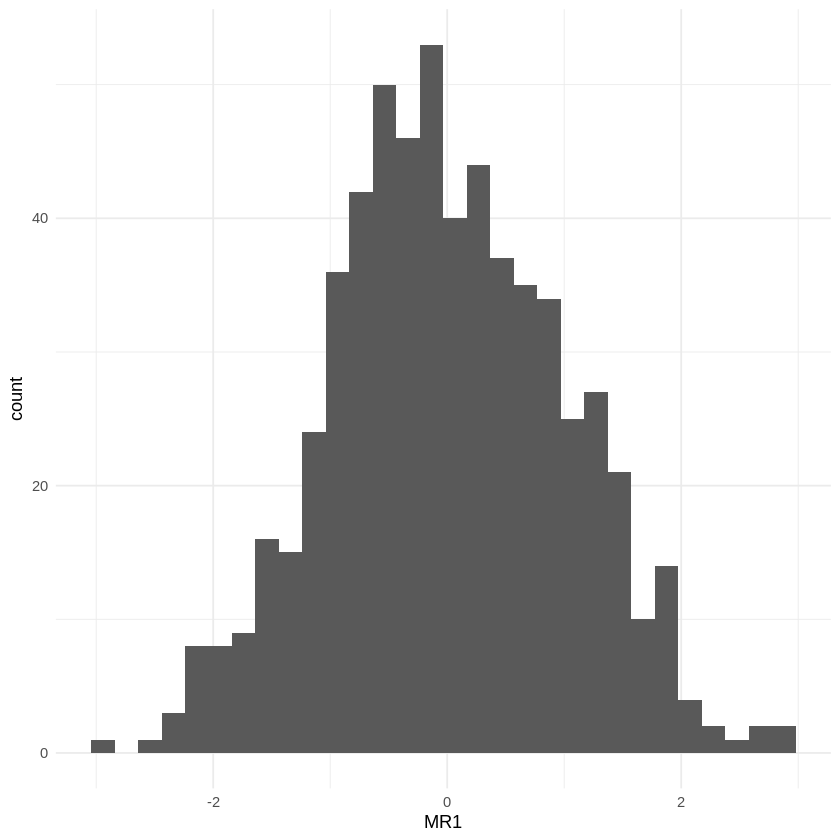

In [89]:
scores_longitudinais[["2025"]] %>%

  ggplot(
    aes(MR1)
  ) +

  geom_histogram(
    bins = 30
  ) +

  theme_minimal()

In [90]:
media_scores <- map_dfr(

  names(scores_longitudinais),

  function(a){

    scores_longitudinais[[a]] %>%

      summarise(

        F1 = mean(MR1, na.rm = TRUE),
        F2 = mean(MR2, na.rm = TRUE),
        F3 = mean(MR3, na.rm = TRUE),
        F4 = mean(MR4, na.rm = TRUE),
        F5 = mean(MR5, na.rm = TRUE)

      ) %>%

      mutate(
        Ano = as.numeric(a)
      )

  }

)

media_scores

F1,F2,F3,F4,F5,Ano
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-5.523797e-17,4.123704e-16,3.792380e-16,-2.315939e-16,-1.104829e-16,2017
-3.961902e-16,5.813012e-17,2.572692e-16,3.720019e-16,-3.397847e-16,2019
8.073574e-16,-9.157065e-19,-2.686197e-16,-6.147142e-17,3.484778e-16,2021
-4.570214e-16,2.327764e-16,-1.460040e-16,-1.225193e-17,2.854040e-18,2023
1.041083e-17,-6.157788e-17,5.154446e-16,2.942304e-16,1.096990e-16,2025


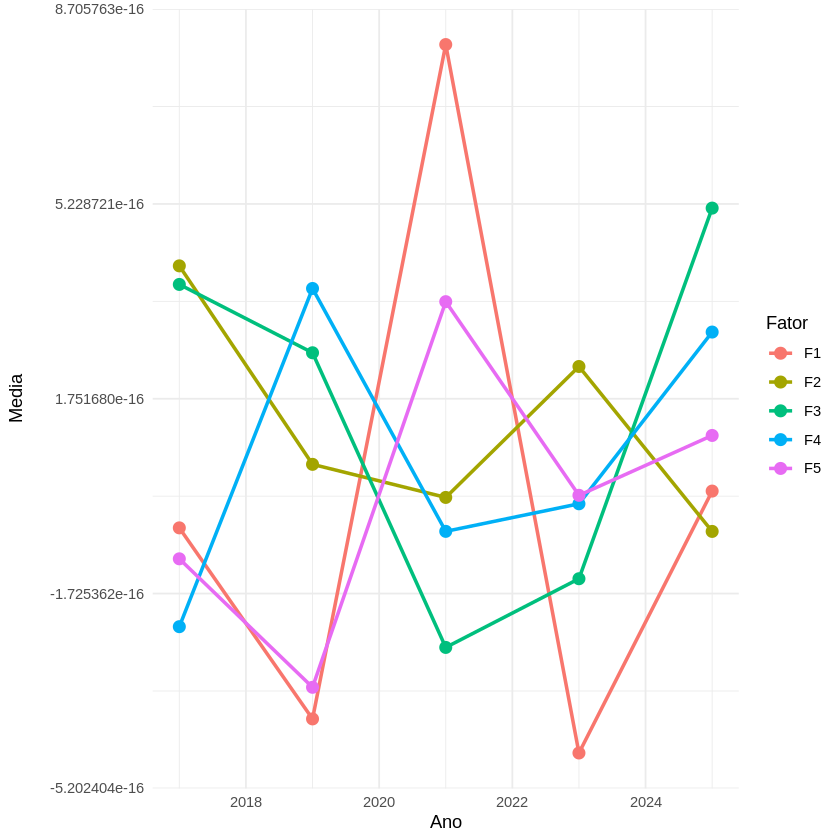

In [91]:
media_scores_long <- media_scores %>%

  pivot_longer(

    F1:F5,

    names_to = "Fator",

    values_to = "Media"

  )

ggplot(

  media_scores_long,

  aes(

    Ano,

    Media,

    color = Fator

  )

) +

  geom_line(
    linewidth = 1
  ) +

  geom_point(
    size = 3
  ) +

  theme_minimal()

In [92]:
for(a in names(segunda_ordem)){

  cat("\nANO:", a, "\n")

  print(
    segunda_ordem[[a]]$loadings,
    cutoff = 0.20
  )

}


ANO: 2017 

Loadings:
    MR1    MR2   
MR4 -0.354  0.291
MR3  0.725       
MR2  0.585  0.246
MR1  0.637       
MR5         0.741

                 MR1   MR2
SS loadings    1.399 0.702
Proportion Var 0.280 0.140
Cumulative Var 0.280 0.420

ANO: 2019 

Loadings:
    MR1    MR2   
MR5 -0.336  0.295
MR3  0.753       
MR4  0.587  0.214
MR2  0.607       
MR1         0.719

                 MR1   MR2
SS loadings    1.393 0.657
Proportion Var 0.279 0.131
Cumulative Var 0.279 0.410

ANO: 2021 

Loadings:
    MR1    MR2   
MR4 -0.326  0.301
MR5  0.778       
MR2  0.592       
MR1  0.560       
MR3         0.651

                 MR1   MR2
SS loadings    1.377 0.573
Proportion Var 0.275 0.115
Cumulative Var 0.275 0.390

ANO: 2023 

Loadings:
    MR1    MR2   
MR1 -0.286 -0.299
MR3  0.793       
MR5  0.610       
MR2  0.512       
MR4         0.684

                 MR1   MR2
SS loadings    1.345 0.598
Proportion Var 0.269 0.120
Cumulative Var 0.269 0.388

ANO: 2025 

Loadings:
    MR2    MR1   

In [93]:
fa.sort(
  efa_5fatores[["2025"]]
)

Factor Analysis using method =  minres
Call: fa(r = cor_mat, nfactors = 5, n.obs = nrow(dados), rotate = "oblimin", 
    fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
                                                                                               MR1
Response Orientation - Level                                                                  0.91
Multilimb Coordination - Level                                                                0.89
Depth Perception - Level                                                                      0.89
Reaction Time - Level                                                                         0.87
Performing General Physical Activities - Level                                                0.86
Static Strength - Level                                                                       0.86
Gross Body Equilibrium - Level                                                                0.85
Ope

In [94]:
scores_longitudinais[["2025"]] |>
  select(MR1, MR2, MR3, MR4, MR5) |>
  summary()

      MR1                MR2                MR3                 MR4           
 Min.   :-2.94342   Min.   :-2.70358   Min.   :-2.668128   Min.   :-3.294175  
 1st Qu.:-0.69774   1st Qu.:-0.69292   1st Qu.:-0.633004   1st Qu.:-0.677753  
 Median :-0.07236   Median :-0.02749   Median :-0.006524   Median :-0.005816  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.000000  
 3rd Qu.: 0.70053   3rd Qu.: 0.65887   3rd Qu.: 0.654108   3rd Qu.: 0.686560  
 Max.   : 2.87764   Max.   : 2.67447   Max.   : 2.966769   Max.   : 3.619002  
      MR5         
 Min.   :-3.0959  
 1st Qu.:-0.6461  
 Median : 0.0275  
 Mean   : 0.0000  
 3rd Qu.: 0.6252  
 Max.   : 3.2384  

In [95]:
for(i in 1:5){

  cat("\n\n====================\n")
  cat("FATOR", i, "\n")
  cat("====================\n")

  cargas <- efa_5fatores[["2025"]]$loadings[,i]

  top <- sort(abs(cargas), decreasing = TRUE)

  print(
    round(
      cargas[names(top)[1:20]],
      3
    )
  )

}



FATOR 1 
                                     Response Orientation - Level 
                                                            0.905 
                                   Multilimb Coordination - Level 
                                                            0.894 
                                         Depth Perception - Level 
                                                            0.889 
                                            Reaction Time - Level 
                                                            0.875 
                   Performing General Physical Activities - Level 
                                                            0.859 
                                          Static Strength - Level 
                                                            0.858 
                                   Gross Body Equilibrium - Level 
                                                            0.855 
                                    Operation and C

### Análise Fatorial Confirmatória

In [96]:
loadings_2025 <- as.data.frame(
  unclass(efa_5fatores[["2025"]]$loadings)
)

In [97]:
itens_fator <- list()

for(f in colnames(loadings_2025)){

  itens_fator[[f]] <-

    loadings_2025 %>%

    mutate(item = rownames(loadings_2025)) %>%

    arrange(desc(abs(.data[[f]]))) %>%

    slice(1:10) %>%

    pull(item)

}

In [ ]:
itens_fator

$MR2
 [1] "Response Orientation - Level"                                     
 [2] "Multilimb Coordination - Level"                                   
 [3] "Depth Perception - Level"                                         
 [4] "Reaction Time - Level"                                            
 [5] "Performing General Physical Activities - Level"                   
 [6] "Static Strength - Level"                                          
 [7] "Gross Body Equilibrium - Level"                                   
 [8] "Operation and Control - Level"                                    
 [9] "Operating Vehicles, Mechanized Devices, or Equipment - Importance"
[10] "Repairing and Maintaining Mechanical Equipment - Importance"      

$MR3
 [1] "Training and Teaching Others - Level"                           
 [2] "Training and Teaching Others - Importance"                      
 [3] "Interpreting the Meaning of Information for Others - Level"     
 [4] "Developing Objectives and Strategies - Level"                   
 [5] "Coaching and Developing Others - Level"                         
 [6] "Interpreting the Meaning of Information for Others - Importance"
 [7] "Developing Objectives and Strategies - Importance"              
 [8] "Coaching and Developing Others - Importance"                    
 [9] "Scheduling Work and Activities - Level"                         
[10] "Guiding, Directing, and Motivating Subordinates - Level"        

$MR5
 [1] "Speed of Closure - Level"            "Flexibility of Closure - Level"     
 [3] "Speed of Closure - Importance"       "Flexibility of Closure - Importance"
 [5] "Perceptual Speed - Level"            "Problem Sensitivity - Level"        
 [7] "Problem Sensitivity - Importance"    "Information Ordering - Importance"  
 [9] "Information Ordering - Level"        "Perceptual Speed - Importance"      

$MR4
 [1] "Sales and Marketing - Importance"              
 [2] "Selling or Influencing Others - Importance"    
 [3] "Sales and Marketing - Level"                   
 [4] "Management of Financial Resources - Level"     
 [5] "Administration and Management - Importance"    
 [6] "Selling or Influencing Others - Level"         
 [7] "Management of Material Resources - Level"      
 [8] "Economics and Accounting - Importance"         
 [9] "Management of Financial Resources - Importance"
[10] "Management of Material Resources - Importance" 

$MR1
 [1] "Assisting and Caring for Others - Importance"                   
 [2] "Assisting and Caring for Others - Level"                        
 [3] "Therapy and Counseling - Importance"                            
 [4] "Design - Importance"                                            
 [5] "Psychology - Importance"                                        
 [6] "Design - Level"                                                 
 [7] "Performing for or Working Directly with the Public - Importance"
 [8] "Engineering and Technology - Importance"                        
 [9] "Engineering and Technology - Level"                             
[10] "Therapy and Counseling - Level"

In [98]:
modelo_cfa <- paste0(
  "Fisico =~ ", paste0("`", itens_fator$MR2, "`", collapse = " + "), "\n",
  "Gestao =~ ", paste0("`", itens_fator$MR3, "`", collapse = " + "), "\n",
  "Cognitivo =~ ", paste0("`", itens_fator$MR5, "`", collapse = " + "), "\n",
  "Negocios =~ ", paste0("`", itens_fator$MR4, "`", collapse = " + "), "\n",
  "Social =~ ", paste0("`", itens_fator$MR1, "`", collapse = " + ")
)

cat(modelo_cfa)

Fisico =~ `Sales and Marketing - Importance` + `Selling or Influencing Others - Importance` + `Sales and Marketing - Level` + `Management of Financial Resources - Level` + `Administration and Management - Importance` + `Selling or Influencing Others - Level` + `Management of Material Resources - Level` + `Economics and Accounting - Importance` + `Management of Financial Resources - Importance` + `Management of Material Resources - Importance`
Gestao =~ `Assisting and Caring for Others - Importance` + `Assisting and Caring for Others - Level` + `Therapy and Counseling - Importance` + `Design - Importance` + `Psychology - Importance` + `Design - Level` + `Performing for or Working Directly with the Public - Importance` + `Engineering and Technology - Importance` + `Engineering and Technology - Level` + `Therapy and Counseling - Level`
Cognitivo =~ `Speed of Closure - Level` + `Flexibility of Closure - Level` + `Speed of Closure - Importance` + `Flexibility of Closure - Importance` + `Per

In [99]:
dados_cfa <- dados %>%
  clean_names()

In [100]:
clean_name <- function(x){

  x <- tolower(x)

  x <- gsub(" - ", "_", x)
  x <- gsub(",", "", x)
  x <- gsub("/", "_", x)
  x <- gsub("\\(", "", x)
  x <- gsub("\\)", "", x)
  x <- gsub(" ", "_", x)

  x
}

In [101]:
itens_fator_limpo <- lapply(
  itens_fator,
  clean_name
)

In [102]:
head(itens_fator_limpo$MR2)

[1] "sales_and_marketing_importance"          
[2] "selling_or_influencing_others_importance"
[3] "sales_and_marketing_level"               
[4] "management_of_financial_resources_level" 
[5] "administration_and_management_importance"
[6] "selling_or_influencing_others_level"

In [103]:
vars_modelo <- unlist(itens_fator_limpo)

setdiff(
  vars_modelo,
  names(dados_cfa)
)

character(0)

In [104]:
modelo_cfa <- paste0(
  "Fisico =~ ", paste(itens_fator_limpo$MR2, collapse = " + "), "\n",
  "Gestao =~ ", paste(itens_fator_limpo$MR3, collapse = " + "), "\n",
  "Cognitivo =~ ", paste(itens_fator_limpo$MR5, collapse = " + "), "\n",
  "Negocios =~ ", paste(itens_fator_limpo$MR4, collapse = " + "), "\n",
  "Social =~ ", paste(itens_fator_limpo$MR1, collapse = " + ")
)

In [105]:
fit <- lavaan::cfa(
  modelo_cfa,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [106]:
fitMeasures(
  fit,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     18405.750       1165.000          0.000          0.598          0.578 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.156          0.154          0.158          0.165

In [ ]:
compRelSEM(fit)

$Fisico

Composite `Fisico` is composed of observed variables:
	response_orientation_level, multilimb_coordination_level, depth_perception_level, reaction_time_level, performing_general_physical_activities_level, static_strength_level, gross_body_equilibrium_level, operation_and_control_level, operating_vehicles_mechanized_devices_or_equipment_importance, repairing_and_maintaining_mechanical_equipment_importance
True-score variance is represented by common factor(s):
	Fisico
Total variance of composite `Fisico` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.966

$Gestao

Composite `Gestao` is composed of observed variables:
	training_and_teaching_others_level, training_and_teaching_others_importance, interpreting_the_meaning_of_information_for_others_level, developing_objectives_and_strategies_level, coaching_and_developing_others_level, interpreting_the_meaning_of_information_for_others_importance, developing_objectives_and_strategies_importance, coaching_and_developing_others_importance, scheduling_work_and_activities_level, guiding_directing_and_motivating_subordinates_level
True-score variance is represented by common factor(s):
	Gestao
Total variance of composite `Gestao` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.955

$Cognitivo

Composite `Cognitivo` is composed of observed variables:
	speed_of_closure_level, flexibility_of_closure_level, speed_of_closure_importance, flexibility_of_closure_importance, perceptual_speed_level, problem_sensitivity_level, problem_sensitivity_importance, information_ordering_importance, information_ordering_level, perceptual_speed_importance
True-score variance is represented by common factor(s):
	Cognitivo
Total variance of composite `Cognitivo` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.945

$Negocios

Composite `Negocios` is composed of observed variables:
	sales_and_marketing_importance, selling_or_influencing_others_importance, sales_and_marketing_level, management_of_financial_resources_level, administration_and_management_importance, selling_or_influencing_others_level, management_of_material_resources_level, economics_and_accounting_importance, management_of_financial_resources_importance, management_of_material_resources_importance
True-score variance is represented by common factor(s):
	Negocios
Total variance of composite `Negocios` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.662

$Social

Composite `Social` is composed of observed variables:
	assisting_and_caring_for_others_importance, assisting_and_caring_for_others_level, therapy_and_counseling_importance, design_importance, psychology_importance, design_level, performing_for_or_working_directly_with_the_public_importance, engineering_and_technology_importance, engineering_and_technology_level, therapy_and_counseling_level
True-score variance is represented by common factor(s):
	Social
Total variance of composite `Social` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.447

In [ ]:
AVE(fit)

Fisico    Gestao Cognitivo  Negocios    Social 
    0.780     0.690     0.637     0.391     0.405

In [ ]:
sqrt(AVE(fit))

Fisico    Gestao Cognitivo  Negocios    Social 
    0.883     0.831     0.798     0.625     0.636

In [ ]:
inspect(fit, "std")$lambda

,Fisico,Gestao,Cognitivo,Negocios,Social
response_orientation_level,0.9549806,0.0000000,0.0000000,0.0000000,0.0000000
multilimb_coordination_level,0.9363927,0.0000000,0.0000000,0.0000000,0.0000000
depth_perception_level,0.9033718,0.0000000,0.0000000,0.0000000,0.0000000
reaction_time_level,0.9554635,0.0000000,0.0000000,0.0000000,0.0000000
performing_general_physical_activities_level,0.8130768,0.0000000,0.0000000,0.0000000,0.0000000
static_strength_level,0.8835104,0.0000000,0.0000000,0.0000000,0.0000000
gross_body_equilibrium_level,0.8107983,0.0000000,0.0000000,0.0000000,0.0000000
operation_and_control_level,0.9096686,0.0000000,0.0000000,0.0000000,0.0000000
operating_vehicles_mechanized_devices_or_equipment_importance,0.8339861,0.0000000,0.0000000,0.0000000,0.0000000
repairing_and_maintaining_mechanical_equipment_importance,0.8431065,0.0000000,0.0000000,0.0000000,0.0000000


In [ ]:
standardizedSolution(fit)

lhs,op,rhs,est.std,se,z,pvalue,ci.lower,ci.upper
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fisico,=~,response_orientation_level,0.9549806,0.004228875,225.82376,0,0.9466921,0.9632690
Fisico,=~,multilimb_coordination_level,0.9363927,0.007383339,126.82511,0,0.9219216,0.9508638
Fisico,=~,depth_perception_level,0.9033718,0.009441378,95.68220,0,0.8848670,0.9218766
Fisico,=~,reaction_time_level,0.9554635,0.004437867,215.29790,0,0.9467654,0.9641615
Fisico,=~,performing_general_physical_activities_level,0.8130768,0.017890424,45.44760,0,0.7780122,0.8481414
Fisico,=~,static_strength_level,0.8835104,0.012927683,68.34252,0,0.8581726,0.9088482
Fisico,=~,gross_body_equilibrium_level,0.8107983,0.021063059,38.49385,0,0.7695155,0.8520812
Fisico,=~,operation_and_control_level,0.9096686,0.008876883,102.47613,0,0.8922703,0.9270670
Fisico,=~,operating_vehicles_mechanized_devices_or_equipment_importance,0.8339861,0.012496759,66.73619,0,0.8094929,0.8584793


In [ ]:
standardizedSolution(fit) |>
  dplyr::filter(op == "=~") |>
  dplyr::arrange(est.std)

lhs,op,rhs,est.std,se,z,pvalue,ci.lower,ci.upper
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Social,=~,design_level,-0.3176267,0.031889076,-9.960362,0,-0.3801282,-0.2551253
Social,=~,design_importance,-0.3174422,0.030306330,-10.474452,0,-0.3768415,-0.2580429
Social,=~,engineering_and_technology_level,-0.2919600,0.033799385,-8.638026,0,-0.3582055,-0.2257144
Social,=~,engineering_and_technology_importance,-0.2874273,0.032565917,-8.826015,0,-0.3512553,-0.2235992
Negocios,=~,sales_and_marketing_importance,0.3679080,0.039244648,9.374730,0,0.2909899,0.4448261
Negocios,=~,sales_and_marketing_level,0.4163296,0.036297825,11.469822,0,0.3451871,0.4874720
Negocios,=~,selling_or_influencing_others_importance,0.4476979,0.036332828,12.322132,0,0.3764869,0.5189089
Negocios,=~,economics_and_accounting_importance,0.4754369,0.040178381,11.833153,0,0.3966887,0.5541851
Social,=~,performing_for_or_working_directly_with_the_public_importance,0.4844467,0.029029072,16.688330,0,0.4275508,0.5413427


### Análise FAtorial Confirmatória 2.0

In [107]:
modelo_5f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level +
operating_vehicles_mechanized_devices_or_equipment_importance +
repairing_and_maintaining_mechanical_equipment_importance

Gestao =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
interpreting_the_meaning_of_information_for_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
interpreting_the_meaning_of_information_for_others_importance +
developing_objectives_and_strategies_importance +
coaching_and_developing_others_importance +
scheduling_work_and_activities_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
speed_of_closure_importance +
flexibility_of_closure_importance +
perceptual_speed_level +
problem_sensitivity_level +
problem_sensitivity_importance +
information_ordering_importance +
information_ordering_level +
perceptual_speed_importance

Negocios =~
management_of_financial_resources_level +
management_of_financial_resources_importance +
management_of_material_resources_level +
management_of_material_resources_importance +
administration_and_management_importance +
selling_or_influencing_others_level

Social =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance +
performing_for_or_working_directly_with_the_public_importance

'

In [108]:
modelo_6f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level +
operating_vehicles_mechanized_devices_or_equipment_importance +
repairing_and_maintaining_mechanical_equipment_importance

Gestao =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
interpreting_the_meaning_of_information_for_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
interpreting_the_meaning_of_information_for_others_importance +
developing_objectives_and_strategies_importance +
coaching_and_developing_others_importance +
scheduling_work_and_activities_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
speed_of_closure_importance +
flexibility_of_closure_importance +
perceptual_speed_level +
problem_sensitivity_level +
problem_sensitivity_importance +
information_ordering_importance +
information_ordering_level +
perceptual_speed_importance

Negocios =~
management_of_financial_resources_level +
management_of_financial_resources_importance +
management_of_material_resources_level +
management_of_material_resources_importance +
administration_and_management_importance +
selling_or_influencing_others_level

Assistencial =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance +
performing_for_or_working_directly_with_the_public_importance

TecnicoCriativo =~
design_importance +
design_level +
engineering_and_technology_importance +
engineering_and_technology_level

'

In [109]:
modelo_2ord <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Gestao =~
training_and_teaching_others_level +
training_and_teaching_others_importance +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +
guiding_directing_and_motivating_subordinates_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
perceptual_speed_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
management_of_financial_resources_importance +
management_of_material_resources_importance

Social =~
assisting_and_caring_for_others_importance +
assisting_and_caring_for_others_level +
therapy_and_counseling_importance +
therapy_and_counseling_level +
psychology_importance

CompetenciaIntelectual =~
Gestao +
Cognitivo +
Negocios

'

In [110]:
modelo_bifactor <- '

Geral =~

response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +

training_and_teaching_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level +

speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +

management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +

assisting_and_caring_for_others_importance +
therapy_and_counseling_importance +
psychology_importance


Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level

Gestao =~
training_and_teaching_others_level +
developing_objectives_and_strategies_level +
coaching_and_developing_others_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance

Social =~
assisting_and_caring_for_others_importance +
therapy_and_counseling_importance +
psychology_importance


Geral ~~ 0*Fisico
Geral ~~ 0*Gestao
Geral ~~ 0*Cognitivo
Geral ~~ 0*Negocios
Geral ~~ 0*Social

Fisico ~~ 0*Gestao
Fisico ~~ 0*Cognitivo
Fisico ~~ 0*Negocios
Fisico ~~ 0*Social

Gestao ~~ 0*Cognitivo
Gestao ~~ 0*Negocios
Gestao ~~ 0*Social

Cognitivo ~~ 0*Negocios
Cognitivo ~~ 0*Social

Negocios ~~ 0*Social

'

In [111]:
fit5 <- cfa(
  modelo_5f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit6 <- cfa(
  modelo_6f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2ord <- cfa(
  modelo_2ord,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit_bi <- cfa(
  modelo_bifactor,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [112]:
print('Modelo de 5 Fatores')
fitMeasures(
  fit5,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de 6 Fatores')
fitMeasures(
  fit6,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Segunda Ordem')
fitMeasures(
  fit2ord,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Bifator')
fitMeasures(
  fit_bi,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

[1] "Modelo de 5 Fatores"


chisq             df         pvalue            cfi            tli 
     11835.894        809.000          0.000          0.694          0.674 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.149          0.147          0.152          0.139

[1] "Modelo de 6 Fatores"


chisq             df         pvalue            cfi            tli 
     13096.392        974.000          0.000          0.693          0.674 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.143          0.141          0.145          0.133

[1] "Modelo de Segunda Ordem"


chisq             df         pvalue            cfi            tli 
      5963.163        344.000          0.000          0.758          0.734 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.164          0.160          0.167          0.131

[1] "Modelo de Bifator"


chisq             df         pvalue            cfi            tli 
       908.887         88.000          0.000          0.915          0.884 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.124          0.116          0.131          0.080

In [113]:
sapply(
  list(
    fit5 = fit5,
    fit6 = fit6,
    fit2ord = fit2ord,
    fit_bi = fit_bi
  ),
  fitMeasures,
  c(
    "cfi",
    "tli",
    "rmsea",
    "srmr",
    "aic",
    "bic"
  )
)

,fit5,fit6,fit2ord,fit_bi
cfi,6.940955e-01,6.932228e-01,7.579722e-01,9.151304e-01
tli,6.744329e-01,6.740098e-01,7.340509e-01,8.842687e-01
rmsea,1.494815e-01,1.428400e-01,1.636408e-01,1.236618e-01
srmr,1.391462e-01,1.325305e-01,1.306049e-01,8.019064e-02
aic,2.659429e+04,3.074729e+04,1.755827e+04,1.143137e+04
bic,2.719452e+04,3.142254e+04,1.795548e+04,1.171383e+04


In [ ]:
print('CR')
compRelSEM(fit_bi)

[1] "CR"


$Geral

Composite `Geral` is composed of observed variables:
	response_orientation_level, multilimb_coordination_level, depth_perception_level, reaction_time_level, training_and_teaching_others_level, developing_objectives_and_strategies_level, coaching_and_developing_others_level, speed_of_closure_level, flexibility_of_closure_level, problem_sensitivity_level, management_of_financial_resources_level, management_of_material_resources_level, administration_and_management_importance, assisting_and_caring_for_others_importance, therapy_and_counseling_importance, psychology_importance
True-score variance is represented by common factor(s):
	Geral, Fisico, Gestao, Cognitivo, Negocios, Social
Total variance of composite `Geral` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.847

$Fisico

Composite `Fisico` is composed of observed variables:
	response_orientation_level, multilimb_coordination_level, depth_perception_level, reaction_time_level
True-score variance is represented by common factor(s):
	Geral, Fisico
Total variance of composite `Fisico` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.965

$Gestao

Composite `Gestao` is composed of observed variables:
	training_and_teaching_others_level, developing_objectives_and_strategies_level, coaching_and_developing_others_level
True-score variance is represented by common factor(s):
	Geral, Gestao
Total variance of composite `Gestao` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.924

$Cognitivo

Composite `Cognitivo` is composed of observed variables:
	speed_of_closure_level, flexibility_of_closure_level, problem_sensitivity_level
True-score variance is represented by common factor(s):
	Geral, Cognitivo
Total variance of composite `Cognitivo` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.919

$Negocios

Composite `Negocios` is composed of observed variables:
	management_of_financial_resources_level, management_of_material_resources_level, administration_and_management_importance
True-score variance is represented by common factor(s):
	Geral, Negocios
Total variance of composite `Negocios` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.87

$Social

Composite `Social` is composed of observed variables:
	assisting_and_caring_for_others_importance, therapy_and_counseling_importance, psychology_importance
True-score variance is represented by common factor(s):
	Geral, Social
Total variance of composite `Social` determined from the unrestricted model.
The proportion attributable to "true" scores is its model-based estimate of reliability ("omega"):

[1] 0.911

In [ ]:
bifactorIndices(fit_bi)

$ModelLevelIndices
   ECV.Geral          PUC  Omega.Geral OmegaH.Geral 
   0.3730874    0.8500000    0.9404102    0.4596685 

$FactorLevelIndices
             ECV_SS     ECV_SG    ECV_GS     Omega    OmegaH         H
Geral     0.3730874 0.37308735 0.3730874 0.9404102 0.4596685 0.8920056
Fisico    0.7838950 0.21538891 0.2161050 0.9665938 0.7601424 0.9039485
Gestao    0.3547950 0.06677545 0.6452050 0.9217268 0.3077565 0.5942709
Cognitivo 0.6026062 0.11320697 0.3973938 0.9189537 0.5662582 0.7913076
Negocios  0.6261493 0.10413199 0.3738507 0.8710984 0.5183728 0.7732436
Social    0.6967731 0.12740932 0.3032269 0.9112008 0.6510277 0.8038808
                 FD
Geral     0.9178751
Fisico    0.9645005
Gestao    0.8649612
Cognitivo 0.9071003
Negocios  0.9308798
Social    0.9431951

$ItemLevelIndices
                                                IECV
response_orientation_level                 0.1846496
multilimb_coordination_level               0.2861944
depth_perception_level                     0.1496534
reaction_time_level                        0.2419852
training_and_teaching_others_level         0.4518194
developing_objectives_and_strategies_level 0.8560610
coaching_and_developing_others_level       0.6893450
speed_of_closure_level                     0.3678198
flexibility_of_closure_level               0.1289887
problem_sensitivity_level                  0.6964669
management_of_financial_resources_level    0.3108524
management_of_material_resources_level     0.2927307
administration_and_management_importance   0.7485690
assisting_and_caring_for_others_importance 0.1234168
therapy_and_counseling_importance          0.2625133
psychology_importance                      0.4797469

In [114]:
modelo_4f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level

Social =~
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

'

In [115]:
modelo_2ordem <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

Cognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level

Negocios =~
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level

Social =~
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

SocioCognitivo =~
Cognitivo +
Negocios +
Social

'

In [116]:
modelo_2f <- '

Fisico =~
response_orientation_level +
multilimb_coordination_level +
depth_perception_level +
reaction_time_level +
performing_general_physical_activities_level +
static_strength_level +
gross_body_equilibrium_level +
operation_and_control_level

SocioCognitivo =~
speed_of_closure_level +
flexibility_of_closure_level +
problem_sensitivity_level +
information_ordering_level +
developing_objectives_and_strategies_level +
interpreting_the_meaning_of_information_for_others_level +
making_decisions_and_solving_problems_level +
critical_thinking_level +
management_of_financial_resources_level +
management_of_material_resources_level +
administration_and_management_importance +
sales_and_marketing_level +
selling_or_influencing_others_level +
guiding_directing_and_motivating_subordinates_level +
scheduling_work_and_activities_level +
assisting_and_caring_for_others_level +
therapy_and_counseling_level +
psychology_importance +
coaching_and_developing_others_level +
training_and_teaching_others_level +
performing_for_or_working_directly_with_the_public_importance

'

In [117]:
fit4 <- cfa(
  modelo_4f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2ordem <- cfa(
  modelo_2ordem,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

fit2 <- cfa(
  modelo_2f,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [118]:
sapply(
  list(
    fit4 = fit4,
    fit2ordem = fit2ordem,
    fit2 = fit2
  ),
  fitMeasures,
  c(
    "cfi",
    "tli",
    "rmsea",
    "srmr",
    "aic",
    "bic"
  )
)

,fit4,fit2ordem,fit2
cfi,6.675699e-01,6.673960e-01,6.112531e-01
tli,6.362086e-01,6.379699e-01,5.802360e-01
rmsea,1.733755e-01,1.729553e-01,1.862362e-01
srmr,1.560154e-01,1.552513e-01,1.283333e-01
aic,2.441884e+04,2.442040e+04,2.556627e+04
bic,2.482929e+04,2.482202e+04,2.595466e+04


In [119]:
print('Modelo de 4 Fatores')
fitMeasures(
  fit4,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de Segunda Ordem')
fitMeasures(
  fit2ordem,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

print('Modelo de 2 Fatores')
fitMeasures(
  fit2,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower",
  "rmsea.ci.upper","srmr")
)

[1] "Modelo de 4 Fatores"


chisq             df         pvalue            cfi            tli 
      7173.664        371.000          0.000          0.668          0.636 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.173          0.170          0.177          0.156

[1] "Modelo de Segunda Ordem"


chisq             df         pvalue            cfi            tli 
      7179.224        373.000          0.000          0.667          0.638 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.173          0.169          0.176          0.155

[1] "Modelo de 2 Fatores"


chisq             df         pvalue            cfi            tli 
      8331.101        376.000          0.000          0.611          0.580 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.186          0.183          0.190          0.128

In [120]:
comparacao <- rbind(

  cbind(
    modelo = "5 fatores",
    fitMeasures(
      fit5,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "4 fatores",
    fitMeasures(
      fit4,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "2 ordem",
    fitMeasures(
      fit2ordem,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  ),

  cbind(
    modelo = "2 fatores",
    fitMeasures(
      fit2,
      c("cfi","tli","rmsea","srmr","aic","bic")
    )
  )

)

comparacao

,modelo,
cfi,5 fatores,0.69409552993423
tli,5 fatores,0.674432943477592
rmsea,5 fatores,0.14948149119263
srmr,5 fatores,0.139146155901891
aic,5 fatores,26594.2861793053
bic,5 fatores,27194.5165974801
cfi,4 fatores,0.667569938424429
tli,4 fatores,0.636208611860696
rmsea,4 fatores,0.173375463732197
srmr,4 fatores,0.15601537810103


In [121]:
cargas <- standardizedSolution(fit) %>%
  filter(op == "=~") %>%
  select(
    fator = lhs,
    item = rhs,
    carga = est.std,
    pvalue
  ) %>%
  arrange(fator, desc(abs(carga)))

cargas

fator,item,carga,pvalue
<chr>,<chr>,<dbl>,<dbl>
Cognitivo,flexibility_of_closure_level,0.8940487,0
Cognitivo,speed_of_closure_level,0.8870151,0
Cognitivo,flexibility_of_closure_importance,0.8656871,0
Cognitivo,speed_of_closure_importance,0.8485325,0
Cognitivo,problem_sensitivity_level,0.8064528,0
Cognitivo,problem_sensitivity_importance,0.8024121,0
Cognitivo,information_ordering_level,0.7705943,0
Cognitivo,information_ordering_importance,0.7627097,0
Cognitivo,perceptual_speed_level,0.6871174,0


In [122]:
itens_removidos <- cargas %>%
  filter(abs(carga) < 0.70)

itens_removidos

fator,item,carga,pvalue
<chr>,<chr>,<dbl>,<dbl>
Cognitivo,perceptual_speed_level,0.6871174,0
Cognitivo,perceptual_speed_importance,0.6244868,0
Fisico,administration_and_management_importance,0.5325354,0
Fisico,selling_or_influencing_others_level,0.4953714,0
Fisico,economics_and_accounting_importance,0.4754372,0
Fisico,selling_or_influencing_others_importance,0.4476988,0
Fisico,sales_and_marketing_level,0.4163307,0
Fisico,sales_and_marketing_importance,0.3679091,0
Gestao,performing_for_or_working_directly_with_the_public_importance,0.4844504,0


In [123]:
itens_mantidos <- cargas %>%
  filter(abs(carga) >= 0.70)

itens_mantidos %>%
  group_by(fator) %>%
  summarise(
    mantidos = n()
  )

fator,mantidos
<chr>,<int>
Cognitivo,8
Fisico,4
Gestao,5
Negocios,10
Social,10


In [ ]:
relatorio <- cargas %>%
  mutate(
    status = ifelse(abs(carga) >= 0.70,
                    "MANTER",
                    "REMOVER")
  ) %>%
  arrange(fator, desc(abs(carga)))

relatorio

fator,item,carga,pvalue,status
<chr>,<chr>,<dbl>,<dbl>,<chr>
Cognitivo,flexibility_of_closure_level,0.8940479,0,MANTER
Cognitivo,speed_of_closure_level,0.8870143,0,MANTER
Cognitivo,flexibility_of_closure_importance,0.8656869,0,MANTER
Cognitivo,speed_of_closure_importance,0.8485319,0,MANTER
Cognitivo,problem_sensitivity_level,0.8064520,0,MANTER
Cognitivo,problem_sensitivity_importance,0.8024112,0,MANTER
Cognitivo,information_ordering_level,0.7705904,0,MANTER
Cognitivo,information_ordering_importance,0.7627093,0,MANTER
Cognitivo,perceptual_speed_level,0.6871161,0,REMOVER


In [ ]:
itens_finais <- cargas %>%
  filter(abs(carga) >= 0.70)

In [ ]:
modelo_refinado <- itens_finais %>%
  group_by(fator) %>%
  summarise(
    sintaxe = paste(item, collapse = " + ")
  ) %>%
  mutate(
    linha = paste0(fator, " =~ ", sintaxe)
  ) %>%
  pull(linha) %>%
  paste(collapse = "\n")

cat(modelo_refinado)

Cognitivo =~ flexibility_of_closure_level + speed_of_closure_level + flexibility_of_closure_importance + speed_of_closure_importance + problem_sensitivity_level + problem_sensitivity_importance + information_ordering_level + information_ordering_importance
Fisico =~ reaction_time_level + response_orientation_level + multilimb_coordination_level + operation_and_control_level + depth_perception_level + static_strength_level + repairing_and_maintaining_mechanical_equipment_importance + operating_vehicles_mechanized_devices_or_equipment_importance + performing_general_physical_activities_level + gross_body_equilibrium_level
Gestao =~ coaching_and_developing_others_level + training_and_teaching_others_level + coaching_and_developing_others_importance + developing_objectives_and_strategies_level + developing_objectives_and_strategies_importance + guiding_directing_and_motivating_subordinates_level + training_and_teaching_others_importance + scheduling_work_and_activities_level + interpreting

In [ ]:
fit_refinado <- cfa(
  modelo_refinado,
  data = dados_cfa,
  estimator = "MLR",
  std.lv = TRUE,
  missing = "fiml"
)

In [ ]:
comparacao <- rbind(

  Original = fitMeasures(
    fit,
    c("cfi","tli","rmsea","srmr","aic","bic")
  ),

  Refinado = fitMeasures(
    fit_refinado,
    c("cfi","tli","rmsea","srmr","aic","bic")
  ),

  Bifator = fitMeasures(
    fit_bi,
    c("cfi","tli","rmsea","srmr","aic","bic")
  )

)

round(comparacao, 3)

,cfi,tli,rmsea,srmr,aic,bic
Original,0.598,0.578,0.156,0.165,37989.96,38696.12
Refinado,0.732,0.712,0.153,0.107,22095.07,22629.10
Bifator,0.915,0.884,0.124,0.080,11431.37,11713.83


In [ ]:
itens_finais %>%
  count(fator)

fator,n
<chr>,<int>
Cognitivo,8
Fisico,10
Gestao,10
Negocios,4
Social,5


In [ ]:
lavInspect(
  fit_refinado,
  "cor.lv"
)

,Cognitivo,Fisico,Gestao,Negocios,Social
Cognitivo,1.0000000,-0.1110976,0.5352845,0.4723204,0.2828825
Fisico,-0.1110976,1.0000000,-0.3375410,-0.1945901,-0.2083183
Gestao,0.5352845,-0.3375410,1.0000000,0.4567376,0.4512965
Negocios,0.4723204,-0.1945901,0.4567376,1.0000000,0.0767388
Social,0.2828825,-0.2083183,0.4512965,0.0767388,1.0000000


In [ ]:
modindices(fit_refinado, minimum.value = 20)

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
134,Cognitivo,=~,multilimb_coordination_level,45.51010,-0.10175648,-0.10175648,-0.10654755,-0.10654755
135,Cognitivo,=~,operation_and_control_level,58.42858,0.12941939,0.12941939,0.13993397,0.13993397
136,Cognitivo,=~,depth_perception_level,62.10068,0.10696439,0.10696439,0.14808215,0.14808215
137,Cognitivo,=~,static_strength_level,91.15074,-0.18648786,-0.18648786,-0.19330600,-0.19330600
141,Cognitivo,=~,gross_body_equilibrium_level,28.57049,-0.09699733,-0.09699733,-0.13306258,-0.13306258
144,Cognitivo,=~,coaching_and_developing_others_importance,27.37943,-0.09598219,-0.09598219,-0.14723589,-0.14723589
148,Cognitivo,=~,training_and_teaching_others_importance,35.47220,-0.12294901,-0.12294901,-0.18105364,-0.18105364
150,Cognitivo,=~,interpreting_the_meaning_of_information_for_others_importance,48.59897,0.15885096,0.15885096,0.22666455,0.22666455
151,Cognitivo,=~,interpreting_the_meaning_of_information_for_others_level,29.99801,0.14756418,0.14756418,0.18051094,0.18051094


In [ ]:
efa <- fa(
  dados_refinados,
  nfactors = 5,
  rotate = "oblimin",
  fm = "ml"
)

ERROR: Error: object 'dados_refinados' not found
